## Import thư viện

In [22]:
# Import thư viện

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math
# from google.colab import drive
# import os
# drive.mount('/content/drive')
# os.chdir('/content/drive/My Drive/Colab Notebooks')

## I. Dữ liệu ban đầu

In [23]:
path = r'C:\Users\PC ACER\OneDrive\Desktop\Data\data_stroke.csv'
first_dataset = pd.read_csv(path)
first_dataset

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4976,Male,41.0,0,0,No,Private,Rural,70.15,29.8,formerly smoked,0
4977,Male,40.0,0,0,Yes,Private,Urban,191.15,31.1,smokes,0
4978,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.8,smokes,0
4979,Male,40.0,0,0,Yes,Private,Rural,83.94,30.0,smokes,0


## Thông tin dữ liệu

In [24]:
# Thông tin dữ liệu ban đầu

print('Số dòng dữ liệu: ', first_dataset.shape[0])
print('Số cột dữ liệu: ', first_dataset.shape[1])
print('Thông tin cơ bản', first_dataset.info())
print('Thống kê mô tả ', first_dataset.describe())

def columns_detail(df) :
  print('Thống kê chi tiết thông tin cấc cột')
  for col in first_dataset.columns:
    print(f"  {col:<20} {str(first_dataset[col].dtype):<15} {first_dataset[col].isnull().sum():<8} {first_dataset[col].nunique()}")
columns_detail(first_dataset)


Số dòng dữ liệu:  4981
Số cột dữ liệu:  11
<class 'pandas.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   str    
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   str    
 5   work_type          4981 non-null   str    
 6   Residence_type     4981 non-null   str    
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   str    
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 428.2 KB
Thông tin cơ bản None
Thống kê mô tả                 age  hypertension  heart_disease  avg_glucose_level  \
count  4981.000000   4981.000000    4981.000000        4981.000000   

## II. Tiền sử lý dữ liệu

In [25]:

# Dữ liệu mising
print('==' * 10 + 'Số dòng dữ liệu bị thiếu:' + '==' * 10)
print(first_dataset.isnull().sum())


print('Thống kê ban đầu của dữu liệu')
print(f"\n Phân phối nhãn stroke:")
vc = first_dataset['stroke'].value_counts()
print(f"   Không đột quỵ (0): {vc[0]}  ({vc[0]/len(first_dataset)*100:.1f}%)")
print(f"   Đột quỵ       (1): {vc[1]}  ({vc[1]/len(first_dataset)*100:.1f}%)")
print(f"   Tỷ lệ mất cân bằng: {vc[0]//vc[1]}:1")

====================Số dòng dữ liệu bị thiếu:====================
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
Thống kê ban đầu của dữu liệu

 Phân phối nhãn stroke:
   Không đột quỵ (0): 4733  (95.0%)
   Đột quỵ       (1): 248  (5.0%)
   Tỷ lệ mất cân bằng: 19:1


## Bước 1: Chia tập dữ liệu (Dataset Splitting)

In [ ]:
# Thuật toán Stratified Sampling (Đã sửa đổi thành 2 tập: Train/Test)

import pandas as pd
import numpy as np

def stratified_split(df, target_column, test_size=0.2):
    classes = df[target_column].unique()
    train_set = []
    test_set = []

    for cls in classes:
        # Lọc ra các bản ghi thuộc lớp hiện tại
        df_class = df[df[target_column] == cls]

        # Xáo trộn ngẫu nhiên dữ liệu của lớp đó
        df_class = df_class.sample(frac=1, random_state=42).reset_index(drop=True)

        # Tính toán điểm cắt dựa trên test_size (mặc định 20% cho Test)
        n_total = len(df_class)
        n_test = round(n_total * test_size)
        n_train = n_total - n_test

        # Chia lớp này thành 2 phần: Train và Test
        df_test_class = df_class.iloc[n_train:]
        df_train_class = df_class.iloc[:n_train]

        # Thêm vào danh sách tổng
        train_set.append(df_train_class)
        test_set.append(df_test_class)

    # 2. Gộp các phần đã chia từ mỗi lớp lại
    final_train = pd.concat(train_set).sample(frac=1, random_state=42)
    final_test = pd.concat(test_set).sample(frac=1, random_state=42)

    return final_train, final_test


# Thực hiện chia dữ liệu (80% Train, 20% Test)
df_train, df_test = stratified_split(first_dataset, 'stroke', test_size=0.2)

# Số lượng phân chia
print(f"Số lượng train: {len(df_train)}")
print(f"Số lượng test: {len(df_test)}")

print('==' * 10 + 'Thông tin sau Chia' + '==' * 10)
vc = df_train['stroke'].value_counts()
print(f"   Không đột quỵ (0): {vc[0]}  ({vc[0]/len(df_train)*100:.1f}%)")
print(f"   Đột quỵ       (1): {vc[1]}  ({vc[1]/len(df_train)*100:.1f}%)")
print(f"   Tỷ lệ mất cân bằng: {vc[0]//vc[1]}:1")

print("\n Class Distribution Ratio (CDR)")
print("     Công thức: |p_tập - p_gốc| / p_gốc × 100%")
print("     Kỳ vọng  : < 1%\n")

p_goc = first_dataset['stroke'].value_counts(normalize=True)

print(f"  {'Tập':<12} {'stroke=0':>10} {'stroke=1':>10} "
          f"{'CDR_0':>10} {'CDR_1':>10} {'Đánh giá':>10}")
print(f"  {'-'*62}")


for ten, tap in [('Gốc', first_dataset), ('Train', df_train), ('Test', df_test)]:
  p = tap['stroke'].value_counts(normalize=True)
  if ten == 'Gốc':
    print(f"  {ten:<12} {p.get(0,0):>10.3f} {p.get(1,0):>10.3f} "f"{'—':>10} {'—':>10} {'(chuẩn)':>10}")
  else:
    cdr0 = abs(p.get(0,0) - p_goc.get(0,0)) / p_goc.get(0,0) * 100
    cdr1 = abs(p.get(1,0) - p_goc.get(1,0)) / p_goc.get(1,0) * 100
    ok   = " Tốt" if max(cdr0, cdr1) < 1 else " Lệch"
    print(f"  {ten:<12} {p.get(0,0):>10.3f} {p.get(1,0):>10.3f} "
             f"{cdr0:>9.2f}% {cdr1:>9.2f}% {ok:>10}")


print(f" Training   : {len(df_train)} dòng ({len(df_train)/len(first_dataset)*100:.0f}%)")
print(f" Testing    : {len(df_test)} dòng ({len(df_test)/len(first_dataset)*100:.0f}%)")


Số lượng train: 3984
Số lượng test: 997
====================Thông tin sau Chia====================
   Không đột quỵ (0): 3786  (95.0%)
   Đột quỵ       (1): 198  (5.0%)
   Tỷ lệ mất cân bằng: 19:1

 Class Distribution Ratio (CDR)
     Công thức: |p_tập - p_gốc| / p_gốc × 100%
     Kỳ vọng  : < 1%

  Tập            stroke=0   stroke=1      CDR_0      CDR_1   Đánh giá
  --------------------------------------------------------------
  Gốc               0.950      0.050          —          —    (chuẩn)
  Train             0.950      0.050      0.01%      0.18%        Tốt
  Test              0.950      0.050      0.04%      0.73%        Tốt
 Training   : 3984 dòng (80%)
 Testing    : 997 dòng (20%)


## Bước 2 : Xử lý ngoại lệ (Outlier Handling)





In [27]:
print('==' * 10 + 'Xử lý ngoại lệ' + '==' * 10)

df_train_clean = df_train.copy()

df_no_outlier = df_train_clean.copy()
outlier_cols = ['bmi', 'avg_glucose_level', 'age']
outlier_report = {}

for col in outlier_cols:
    Q1  = df_no_outlier[col].quantile(0.25)
    Q3  = df_no_outlier[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_out = ((df_no_outlier[col] < lower) | (df_no_outlier[col] > upper)).sum()

    outlier_report[col] = {
        'lower': lower,
        'upper': upper,
        'n_outliers': n_out
    }

    # ✔ FIX: clip thay vì xóa
    df_no_outlier[col] = df_no_outlier[col].clip(lower, upper)
    print(f"{col:<22} | Clip {n_out} outlier → [{lower:.1f}, {upper:.1f}]")

print(f"\n Sau xử lý outlier: {len(df_no_outlier)} dòng "
      f"(xóa {len(df_train_clean) - len(df_no_outlier)} dòng)")

====================Xử lý ngoại lệ====================
bmi                    | Clip 35 outlier → [10.7, 45.9]
avg_glucose_level      | Clip 481 outlier → [22.1, 169.3]
age                    | Clip 0 outlier → [-26.5, 113.5]

 Sau xử lý outlier: 3984 dòng (xóa 0 dòng)


## Bước 3 : Mã hóa dữ liệu phân loại (Categorical Data Encoding)





In [ ]:
print('==' * 10 + ' Mã hóa dữ liệu phân loại (Categorical Data Encoding)' + '==' * 10)

df_encoded = df_no_outlier.copy()
# Mã hóa dữu liệu sang số


for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].str.replace(' ', '_')

    
df_encoded = pd.get_dummies(
    df_encoded,
    columns=[
        'gender',
        'ever_married',
        'Residence_type',
        'smoking_status',
        'work_type'
    ],
    drop_first=True
)
print(f"\n Kiểm tra sau mã hóa (5 dòng đầu):")
print(df_encoded.head())
print(f"\n   Giá trị null còn lại: {df_encoded.isnull().sum().sum()}")

print(f"\n Sau mã hóa: {len(df_encoded)} dòng")

print(f"\n Kiểu dữ liệu : {df_encoded.dtypes}")

print('==' * 20 + 'Dữ liệu sau khi mã hóa' + '==' * 20)

print(df_encoded)

==================== Mã hóa dữ liệu phân loại (Categorical Data Encoding)====================

 Kiểm tra sau mã hóa (5 dòng đầu):
       age  hypertension  heart_disease  avg_glucose_level   bmi  stroke  \
210   71.0             0              0           169.3125  30.3       0   
2349  23.0             0              0            87.8700  23.4       0   
484   55.0             0              0            99.6400  20.1       0   
2961  37.0             0              0            80.2000  30.9       0   
2158  39.0             0              0            69.3800  22.1       0   

      gender_Male  ever_married_Yes  Residence_type_Urban  \
210         False              True                 False   
2349         True             False                  True   
484         False              True                 False   
2961         True              True                 False   
2158        False              True                 False   

      smoking_status_formerly_smoked  smoking_

C:\Users\PC ACER\AppData\Local\Temp\ipykernel_22040\1651435456.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include=['object']).columns:


## Bước 4 : Chuẩn hóa thuộc tính (Attribute Scaling)

In [29]:
# Min-Max Scaling

def min_max_scaling(values) :
  x_min = min(values)
  x_max = max(values)
  denom = x_max - x_min

  if denom == 0:
    return [0.0] * len(values), x_min, x_max
  scaled_values = [(x - x_min) / denom for x in values]
  return scaled_values, x_min, x_max


def apply_scaling(df, columns):
    stats = {}

    for col in columns:
        x_min = df[col].min()
        x_max = df[col].max()
        denom = x_max - x_min

        stats[col] = {'min': x_min, 'max': x_max}

        if denom == 0:
            df[col] = 0.0
        else:
            df[col] = ((df[col] - x_min) / denom).round(6)

    return df, stats
# , 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type'
# Các cột cần chuyển hóa
df_encoded = df_encoded.reset_index(drop=True)  # ← thêm dòng này
numeric_col = ['age', 'avg_glucose_level', 'bmi']

df_after_scaling, stats = apply_scaling(df_encoded, numeric_col)

for col, s in stats.items():
    print(f"{col:<22} min={s['min']:.2f}  max={s['max']:.2f}")



# Dữ liệu sau khi chuẩn hóa

print('==' * 10 + 'Dữ liệu sau khi chuẩn hóa' + '==' * 10)
df_after_scaling

age                    min=0.08  max=82.00
avg_glucose_level      min=55.12  max=169.31
bmi                    min=14.00  max=45.90
====================Dữ liệu sau khi chuẩn hóa====================


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,Residence_type_Urban,smoking_status_formerly_smoked,smoking_status_never_smoked,smoking_status_smokes,work_type_Private,work_type_Self-employed,work_type_children
0,0.865723,0,0,1.000000,0.510972,0,False,True,False,False,False,True,False,True,False
1,0.279785,0,0,0.286796,0.294671,0,True,False,True,False,True,False,True,False,False
2,0.670410,0,0,0.389868,0.191223,0,False,True,False,True,False,False,False,False,False
3,0.450684,0,0,0.219629,0.529781,0,True,True,False,False,True,False,False,False,False
4,0.475098,0,0,0.124877,0.253918,0,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3979,0.523926,0,0,0.404843,0.570533,0,False,False,False,False,True,False,False,False,False
3980,0.719238,1,0,1.000000,0.526646,0,False,True,True,False,True,False,True,False,False
3981,0.658203,0,0,0.474199,0.934169,0,False,True,False,True,False,False,True,False,False
3982,0.017090,0,0,0.003415,0.141066,0,False,False,False,False,False,False,False,False,True


## Bước 5 : Xử lý dữ liệu Imbalenced

In [30]:
print('Thông tin dữ liệu trước khi xử lý dữ liệu imbalanced')

print('==' * 10 + 'Thông tin sau khi Encode (Tập Train 80%)' + '==' * 10)
vc = df_after_scaling['stroke'].value_counts()
print(f"   Không đột quỵ (0): {vc[0]}  ({vc[0]/len(df_train)*100:.1f}%)")
print(f"   Đột quỵ       (1): {vc[1]}  ({vc[1]/len(df_train)*100:.1f}%)")
print(f"   Tỷ lệ mất cân bằng: {vc[0]//vc[1]}:1")


print('=' * 10 + 'Tách Feature' + '=' * 10)

# X_train, y_train lấy từ df_after_scaling (đã chứa 80% dữ liệu)
X_train = df_after_scaling.drop(columns=['stroke']).values
y_train = df_after_scaling['stroke'].values

# KHÔNG còn X_val, y_val ở đây

# X_test, y_test sẽ được tiền xử lý riêng bằng hàm preprocess_split ở cell phía sau
# Ở bước này chúng ta chỉ xác nhận đã tách thành công tập Train
print('Đã tách tập Train thành công')

df_after_scaling.info()


Thông tin dữ liệu trước khi xử lý dữ liệu imbalanced
====================Thông tin sau khi Encode (Tập Train 80%)====================
   Không đột quỵ (0): 3786  (95.0%)
   Đột quỵ       (1): 198  (5.0%)
   Tỷ lệ mất cân bằng: 19:1
==========Tách Feature==========
Đã tách tập Train thành công
<class 'pandas.DataFrame'>
RangeIndex: 3984 entries, 0 to 3983
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             3984 non-null   float64
 1   hypertension                    3984 non-null   int64  
 2   heart_disease                   3984 non-null   int64  
 3   avg_glucose_level               3984 non-null   float64
 4   bmi                             3984 non-null   float64
 5   stroke                          3984 non-null   int64  
 6   gender_Male                     3984 non-null   bool   
 7   ever_married_Yes                3984 non-null   bool   


## 5.1 Áp dụng SMOTE

In [31]:
import numpy as np

# Hai hàm này bạn đang không dùng bên trong SMOTE (SMOTE đã dùng vectorization trực tiếp)
# Nhưng nếu bạn có dùng ở chỗ khác thì cứ giữ lại
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def get_neighbors(X, x, k=5):
    X = np.asarray(X, dtype=float)                         
    x = np.asarray(x, dtype=float)                          
    distances = np.linalg.norm(X - x, axis=1)              
    sorted_idx   = np.argsort(distances)
    mask = distances[sorted_idx] > 0    
    neighbor_idx = sorted_idx[mask][:k]
    return X[neighbor_idx]

# ĐÃ SỬA: Thêm tham số sampling_ratio (Mặc định 0.5 nghĩa là thiểu số bằng 50% đa số)
def SMOTE(X, y, minority_class=1, k=5, sampling_ratio=0.5, random_state=42):   
    rng   = np.random.RandomState(random_state)              
    X     = np.asarray(X, dtype=float)                       
    y     = np.asarray(y)

    X_min = X[y == minority_class]
    X_maj = X[y != minority_class]

    n_min = len(X_min)
    n_maj = len(X_maj)
    
    # Tính toán số lượng mẫu thiểu số mục tiêu dựa trên tỷ lệ sampling_ratio
    target_min_samples = int(n_maj * sampling_ratio)
    
    # Số lượng mẫu CẦN SINH THÊM
    n_new = max(0, target_min_samples - n_min)                            
    
    # Nếu số lượng hiện tại đã đạt hoặc vượt tỷ lệ mong muốn thì không làm gì cả
    if n_new == 0:
        return X, y
        
    k_actual = min(k, n_min - 1) if n_min > 1 else 1
    
    # Tính khoảng cách và tìm K hàng xóm gần nhất (giữ nguyên logic gốc của bạn)
    dists = np.linalg.norm(X_min[:, None] - X_min[None, :], axis=2)
    np.fill_diagonal(dists, np.inf)           
    knn_idx = np.argsort(dists, axis=1)[:, :k_actual]   
    synthetic = np.empty((n_new, X_min.shape[1]))

    for _ in range(n_new):
        i   = rng.randint(0, n_min)                          
        nn     = knn_idx[i, rng.randint(0, k_actual)]
        gap    = rng.rand()
        synthetic[_] = X_min[i] + gap * (X_min[nn] - X_min[i])

    X_res = np.vstack((X, synthetic))
    y_res = np.hstack((y, np.full(n_new, minority_class, dtype=int)))

    return X_res, y_res


# ---------------- KIỂM TRA THỬ ----------------
# Nếu file hiện tại đang dùng biến X_train_goc (ở phần sửa leakage) thì dùng X_train_goc nhé
# X_train_smote, y_train_smote = SMOTE(X_train_goc, y_train_goc, sampling_ratio=0.5)

X_train_smote, y_train_smote = SMOTE(X_train, y_train, sampling_ratio=0.3)

print("Before SMOTE:", np.bincount(y_train))
print("After  SMOTE:", np.bincount(y_train_smote))


Before SMOTE: [3786  198]
After  SMOTE: [3786 1135]


## 5.2 : Áp dụng Class_weight

In [32]:
# def compute_class_weight(y):
#      classes = np.unique(y)        # Lấy Unique từ lớp dữ đoán
#      total = len(y)                # Lấy tổng số mẫu

#      weights = {}                  # Tạo một set rỗng
#      for c in classes:             # Duyệt qua giá trị
#          weights[c] = total / (len(classes) * np.sum(y == c))  # trả về weight

#      return weights
# class_weights = compute_class_weight(y_train)
# print(class_weights)

## 5.3 : SMOTE + Class_Weight

In [33]:
# # SMOTE trước
# X_train_smote, y_train_smote = SMOTE(X_train, y_train)

# # tính weight sau SMOTE
# class_weights_smote = compute_class_weight(y_train_smote)



## Tiền Sử Lý Với  Test

In [ ]:
# Tiền xử lý tập Test (Dựa trên thông số của tập Train)

def preprocess_split(df, scaling_stats, numeric_cols, feature_cols,
                     outlier_report=None, outlier_cols=None,
                     bmi_median=None):
    df = df.copy().reset_index(drop=True)

    if bmi_median is not None and 'bmi' in df.columns:
        n_nan = df['bmi'].isnull().sum()
        if n_nan > 0:
            df['bmi'] = df['bmi'].fillna(bmi_median)
            print(f"    Imputed {n_nan} NaN bmi với median={bmi_median:.2f}")

    if outlier_report is not None and outlier_cols is not None:
        for col in outlier_cols:
            if col in df.columns and col in outlier_report:
                lower = outlier_report[col]['lower']
                upper = outlier_report[col]['upper']
                n_clip = ((df[col] < lower) | (df[col] > upper)).sum()
                df[col] = df[col].clip(lower, upper)
                if n_clip > 0:
                    print(f"    Clip {n_clip} outlier [{col}] → [{lower:.2f}, {upper:.2f}]")
    
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.replace(' ', '_')

    df = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type',
                                      'Residence_type', 'smoking_status'],
                        drop_first=True)

    df = df.reindex(columns=feature_cols, fill_value=0)

    for col in numeric_cols:
        if col in df.columns and col in scaling_stats:
            x_min  = scaling_stats[col]['min']
            x_max  = scaling_stats[col]['max']
            denom  = x_max - x_min
            df[col] = df[col].apply(
                lambda x: round((x - x_min) / denom, 6) if denom != 0 else 0.0
            )

    return df


bmi_median = df_train['bmi'].median()
feature_cols = df_after_scaling.drop(columns=['stroke']).columns.tolist()

# CHỈ xử lý tập Test
df_test_proc = preprocess_split(
    df_test.drop(columns=['stroke']),
    scaling_stats  = stats,
    numeric_cols   = numeric_col,
    feature_cols   = feature_cols,
    outlier_report = outlier_report,
    outlier_cols   = outlier_cols,
    bmi_median     = bmi_median
)

X_test_proc = df_test_proc.values.astype(float)
y_test_proc = df_test['stroke'].values

print(f"\nX_train_smote : {X_train_smote.shape}")
print(f"X_test_proc   : {X_test_proc.shape}")
print(f"NaN test : {np.isnan(X_test_proc).sum()}")

n_train_features = df_after_scaling.drop(columns=['stroke']).shape[1]
assert X_test_proc.shape[1] == n_train_features, " Test columns không khớp train!"
print(f"\n Số cột khớp: Train={n_train_features}, Test={X_test_proc.shape[1]}")


    Clip 8 outlier [bmi] → [10.70, 45.90]
    Clip 121 outlier [avg_glucose_level] → [22.05, 169.31]

X_train_smote : (4921, 14)
X_test_proc   : (997, 14)
NaN test : 0

 Số cột khớp: Train=14, Test=14


C:\Users\PC ACER\AppData\Local\Temp\ipykernel_22040\242750574.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


## EVALUATION METRIC ( Đánh Giá Mô Hình )

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def confusion_matrix_scratch(y_true, y_pred):
    """Tính Confusion Matrix cho binary classification (Tối ưu tốc độ với bincount)"""
    # 0: TN, 1: FP, 2: FN, 3: TP
    b = np.bincount(y_true * 2 + y_pred, minlength=4)
    return np.array([[b[0], b[1]], [b[2], b[3]]])

def _f1_scratch(y_true, y_pred, pos_label=1):
    """Tính F1 score từ scratch"""
    TP = np.sum((y_pred == pos_label) & (y_true == pos_label))
    FP = np.sum((y_pred == pos_label) & (y_true != pos_label))
    FN = np.sum((y_pred != pos_label) & (y_true == pos_label))
    eps = 1e-15
    p  = TP / (TP + FP + eps)
    r  = TP / (TP + FN + eps)
    return 2 * p * r / (p + r + eps)

def _recall_scratch(y_true, y_pred, pos_label=1):
    """Tính Recall (Sensitivity) từ scratch"""
    TP = np.sum((y_pred == pos_label) & (y_true == pos_label))
    FN = np.sum((y_pred != pos_label) & (y_true == pos_label))
    return TP / (TP + FN + 1e-10)

def _accuracy_scratch(y_true, y_pred):
    """Tính Accuracy từ scratch"""
    return np.mean(y_true == y_pred)

def _auc_scratch_fixed(y_true, y_proba):
    """
    Tính ROC-AUC từ scratch - FIXED VERSION
    Tối ưu siêu tốc độ O(N log N) bằng kỹ thuật Vectorized Cumsum.
    """
    desc_idx = np.argsort(y_proba)[::-1]
    y_true_sorted = y_true[desc_idx]
    y_proba_sorted = y_proba[desc_idx]

    distinct_idx = np.where(np.diff(y_proba_sorted))[0]
    thresh_idx = np.r_[distinct_idx, y_true_sorted.size - 1]

    tps = np.cumsum(y_true_sorted)[thresh_idx]
    fps = 1 + thresh_idx - tps

    tps = np.r_[0, tps]
    fps = np.r_[0, fps]

    if tps[-1] == 0 or fps[-1] == 0:
        return np.nan

    tprs = tps / tps[-1]
    fprs = fps / fps[-1]

    auc = float(np.trapezoid(tprs, fprs))
    return np.clip(auc, 0.0, 1.0)

def compute_metrics(y_true, y_pred, y_proba=None, model_name="Model"):
    """Tính toàn bộ metrics và in kết quả đẹp."""
    cm = confusion_matrix_scratch(y_true, y_pred)
    TN, FP = cm[0]
    FN, TP = cm[1]

    eps = 1e-10
    accuracy  = (TP + TN) / (TP + TN + FP + FN + eps)
    precision = TP / (TP + FP + eps)
    recall    = TP / (TP + FN + eps)  # Sensitivity / TPR
    specificity = TN / (TN + FP + eps)  # TNR
    f1        = (2 * precision * recall / (precision + recall + eps))

    auc = None
    if y_proba is not None:
        auc = _auc_scratch_fixed(y_true, y_proba)

    print(f"\n{'═'*56}")
    print(f"    {model_name}")
    print(f"{'═'*56}")
    print(f"  {'Metric':<25} {'Value':>12} {'Meaning':<15}")
    print(f"  {'-'*56}")
    print(f"  {'Accuracy':<25} {accuracy:>12.4f}  Overall correct")
    print(f"  {'Precision':<25} {precision:>12.4f}  Of positive predictions")
    print(f"  {'Recall (Sensitivity)':<25} {recall:>12.4f}  Of actual positives")
    print(f"  {'Specificity (TNR)':<25} {specificity:>12.4f}  Of actual negatives")
    print(f"  {'F1-Score':<25} {f1:>12.4f}  Harmonic mean P&R")
    if auc is not None:
        print(f"  {'ROC-AUC':<25} {auc:>12.4f}  Imbalance-resistant")

    print(f"\n  Confusion Matrix:")
    print(f"  {'Predicted →':>25}    Negative    Positive")
    print(f"  {'Actual Negative':>25}      {TN:>5}       {FP:>5}")
    print(f"  {'Actual Positive':>25}      {FN:>5}       {TP:>5}")
    print(f"\n  Interpretation:")
    print(f"    TP={TP}: Correctly detected positive (good)")
    print(f"    TN={TN}: Correctly detected negative (good)")
    print(f"    FP={FP}: False positive (unnecessary alarm)")
    print(f"    FN={FN}: False negative (missed positive) ⚠️")
    print(f"{'═'*56}\n")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm,
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN
    }

def plot_roc_auc(y_true, y_proba, model_name="Model", ax=None):
    """Vẽ ROC Curve và tính AUC (Áp dụng Vectorized cực nhanh)"""
    desc_idx = np.argsort(y_proba)[::-1]
    y_true_sorted = y_true[desc_idx]
    y_proba_sorted = y_proba[desc_idx]

    distinct_idx = np.where(np.diff(y_proba_sorted))[0]
    thresh_idx = np.r_[distinct_idx, y_true_sorted.size - 1]

    tps = np.cumsum(y_true_sorted)[thresh_idx]
    fps = 1 + thresh_idx - tps

    tps = np.r_[0, tps]
    fps = np.r_[0, fps]

    tprs = tps / tps[-1] if tps[-1] > 0 else tps
    fprs = fps / fps[-1] if fps[-1] > 0 else fps

    auc = _auc_scratch_fixed(y_true, y_proba)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(fprs, tprs, lw=2.5, label=f'{model_name} (AUC = {auc:.3f})', color='#3266ad')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random classifier')
    ax.fill_between(fprs, tprs, alpha=0.2, color='#3266ad')

    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    ax.set_ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
    ax.set_title(f'ROC Curve: {model_name}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

    return auc

def plot_confusion_matrix(cm, model_name="Model", ax=None):
    """Vẽ Confusion Matrix dưới dạng heatmap"""
    import matplotlib.patches as mpatches

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    TN, FP = cm[0]
    FN, TP = cm[1]

    total = TN + FP + FN + TP
    data = np.array([[TN/total*100, FP/total*100],
                     [FN/total*100, TP/total*100]])

    im = ax.imshow(data, cmap='Blues', aspect='auto', vmin=0, vmax=100)

    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, f'{data[i, j]:.1f}%\n({int(cm[i, j])})',
                          ha="center", va="center", color="black", fontsize=12, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred. Neg.', 'Pred. Pos.'], fontsize=11)
    ax.set_yticklabels(['Actual Neg.', 'Actual Pos.'], fontsize=11)

    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_title(f'Confusion Matrix: {model_name}', fontsize=13, fontweight='bold')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Percentage (%)', fontsize=11)

    return ax


## GRID SEACH


In [36]:
from itertools import product
import numpy as np

class NotFittedError(ValueError, AttributeError):
    pass

# ── 1. Thêm 2 hàm phụ trợ tính toán trọng số lớp (Rất quan trọng) ──
def compute_class_weight(y):
    """Tính trọng số cân bằng: w_c = n / (n_classes * n_c)"""
    classes = np.unique(y)
    n = len(y)
    return {c: n / (len(classes) * np.sum(y == c)) for c in classes}

def get_sample_weights(y):
    """Chuyển class weight thành mảng per-sample weight array"""
    cw = compute_class_weight(y)
    return np.array([cw[yi] for yi in y])


# ── 2. Cập nhật class GridSearch ──
class GridSearch:
    """
    Grid Search 
    [ĐÃ CẬP NHẬT]: Hỗ trợ use_class_weight
    """

    def __init__(self, model_class, param_grid,
                 cv=3, scoring='f1',
                 model_name='Model',
                 ada_tree_class=None,
                 smote_func=None,
                 use_class_weight=False,
                 random_state=42,
                 refit=True,
                 verbose=True):

        self.model_class      = model_class
        self.param_grid       = param_grid
        self.cv               = cv
        self.scoring          = scoring
        self.model_name       = model_name
        self.ada_tree_class   = ada_tree_class
        self.smote_func       = smote_func
        self.use_class_weight = use_class_weight 
        self.random_state     = random_state
        self.refit            = refit
        self.verbose          = verbose

        self.best_params_     = None
        self.best_score_      = -np.inf
        self.best_estimator_  = None
        self.best_index_      = None
        self.cv_results_      = {}
        self.n_splits_        = cv
        self._is_fitted       = False

    @property
    def best_model_(self):
        return self.best_estimator_

    def _stratified_folds(self, y):
        rng     = np.random.RandomState(self.random_state)
        classes = np.unique(y)
        fold_indices = [[] for _ in range(self.cv)]

        for cls in classes:
            cls_idx = np.where(y == cls)[0]
            rng.shuffle(cls_idx)
            splits = np.array_split(cls_idx, self.cv)
            for k, split in enumerate(splits):
                fold_indices[k].extend(split.tolist())

        folds   = []
        all_idx = np.arange(len(y))
        for k in range(self.cv):
            val_idx   = np.array(fold_indices[k])
            mask      = np.ones(len(y), dtype=bool)
            mask[val_idx] = False          
            train_idx = all_idx[mask]
            folds.append((train_idx, val_idx))
        return folds

    def _score(self, model, X, y):
        y_pred = model.predict(X)
        if self.scoring == 'f1':
            return _f1_scratch(y, y_pred)
        elif self.scoring == 'recall':
            return _recall_scratch(y, y_pred)
        elif self.scoring == 'accuracy':
            return _accuracy_scratch(y, y_pred)
        elif self.scoring == 'auc':
            if hasattr(model, 'predict_proba'):
                return _auc_scratch_fixed(y, model.predict_proba(X)[:, 1])
            return _f1_scratch(y, y_pred)
        else:
            raise ValueError(f"Scoring '{self.scoring}' không hỗ trợ.")

    def _fit_model(self, model, X, y):
        # <--- CẬP NHẬT PHẦN TRUYỀN TRỌNG SỐ CHO MODEL TẠI ĐÂY
        sw = get_sample_weights(y) if self.use_class_weight else None
        
        if self.ada_tree_class is not None:
            if sw is not None:
                try: model.fit(X, y, self.ada_tree_class, sample_weight=sw)
                except TypeError: model.fit(X, y, self.ada_tree_class)
            else:
                model.fit(X, y, self.ada_tree_class)
        else:
            if sw is not None:
                try:
                    model.fit(X, y, sample_weight=sw)
                except TypeError:
                    # KNN không hỗ trợ sample_weight -> tự động bỏ qua an toàn
                    model.fit(X, y)
            else:
                model.fit(X, y)

    def _check_is_fitted(self):
        if not self._is_fitted or not hasattr(self, 'best_estimator_'):
            raise NotFittedError("GridSearch chưa được fit.")

    def fit(self, X, y, X_val=None, y_val=None):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        param_names  = list(self.param_grid.keys())
        param_values = [self.param_grid[k] for k in param_names]
        all_combos   = list(product(*param_values))
        total        = len(all_combos)

        mode_str  = "Val Set" if (X_val is not None) else f"Stratified {self.cv}-Fold CV"
        smote_str = "Có" if self.smote_func else "Không"
        cw_str    = "Có" if self.use_class_weight else "Không" # <--- Thêm in log

        if self.verbose:
            print(f"\n{'═'*65}")
            print(f"  Grid Search : {self.model_name}")
            print(f"  Scoring     : {self.scoring.upper()} | Mode: {mode_str}")
            print(f"  SMOTE       : {smote_str} | Class Weight: {cw_str}")
            print(f"  Tổng tổ hợp : {total}")
            print(f"{'═'*65}")
            
        if X_val is not None:
            X_val = np.asarray(X_val, dtype=float)
            y_val = np.asarray(y_val)
            X_tr_base, y_tr_base = (
                self.smote_func(X, y) if self.smote_func else (X, y)
            )
        else:
            folds = self._stratified_folds(y)

        raw_results = []
        self.best_score_ = -np.inf

        for i, combo in enumerate(all_combos):
            params = dict(zip(param_names, combo))

            if X_val is not None:
                model = self.model_class(**params)
                self._fit_model(model, X_tr_base, y_tr_base)
                score       = self._score(model, X_val, y_val)
                fold_scores = [score]
                std         = 0.0
            else:
                fold_scores = []
                for train_idx, val_idx in folds:
                    Xf_tr, yf_tr   = X[train_idx], y[train_idx]
                    Xf_val, yf_val = X[val_idx],   y[val_idx]
                    if self.smote_func is not None:
                        Xf_tr, yf_tr = self.smote_func(Xf_tr, yf_tr)
                    m = self.model_class(**params)
                    self._fit_model(m, Xf_tr, yf_tr)
                    fold_scores.append(self._score(m, Xf_val, yf_val))
                score = np.mean(fold_scores)
                std   = np.std(fold_scores)

            raw_results.append({
                'params'          : params,
                'mean_test_score' : score,          
                'std_test_score'  : std,            
                'split_scores'    : fold_scores,    
            })

            if self.verbose:
                marker    = " ← best" if score > self.best_score_ else ""
                param_str = ", ".join(f"{k}={v}" for k, v in params.items())
                std_str   = f"±{std:.4f}" if X_val is None else ""
                print(f"  [{i+1:>3}/{total}] {param_str:<48} "
                      f"{self.scoring}={score:.4f} {std_str}{marker}")

            if score > self.best_score_:
                self.best_score_  = score
                self.best_params_ = params
                self.best_index_  = i

        sorted_idx = sorted(range(len(raw_results)),
                            key=lambda x: raw_results[x]['mean_test_score'],
                            reverse=True)
        rank_map = {idx: rank + 1 for rank, idx in enumerate(sorted_idx)}
        for i, res in enumerate(raw_results):
            res['rank_test_score'] = rank_map[i]   

        self.cv_results_ = {
            'params'          : [r['params'] for r in raw_results],
            'mean_test_score' : np.array([r['mean_test_score'] for r in raw_results]),
            'std_test_score'  : np.array([r['std_test_score']  for r in raw_results]),
            'rank_test_score' : np.array([r['rank_test_score'] for r in raw_results]),
        }
        n_splits = len(raw_results[0]['split_scores'])
        for k in range(n_splits):
            self.cv_results_[f'split{k}_test_score'] = np.array(
                [r['split_scores'][k] for r in raw_results]
            )

        if self.refit:
            if self.verbose:
                print(f"\n{'─'*65}")
                print(f"   Best params : {self.best_params_}")
                print(f"   Best score  : {self.best_score_:.4f} ({self.scoring.upper()})")
                print(f"   Retraining  : full training data...")

            self.best_estimator_ = self.model_class(**self.best_params_)
            X_final, y_final = (
                self.smote_func(X, y) if self.smote_func else (X, y)
            )
            self._fit_model(self.best_estimator_, X_final, y_final)

            if self.verbose:
                print(f"  Done!")
                print(f"{'═'*65}\n")

        self._is_fitted = True
        return self

    def predict(self, X):
        self._check_is_fitted()
        if not self.refit:
            raise NotFittedError("predict không khả dụng khi refit=False.")
        return self.best_estimator_.predict(np.asarray(X, dtype=float))

    def predict_proba(self, X):
        self._check_is_fitted()
        if not self.refit:
            raise NotFittedError("predict_proba không khả dụng khi refit=False.")
        if not hasattr(self.best_estimator_, 'predict_proba'):
            raise AttributeError(f"{type(self.best_estimator_).__name__} không có predict_proba.")
        return self.best_estimator_.predict_proba(np.asarray(X, dtype=float))

    def score(self, X, y):
        self._check_is_fitted()
        if not self.refit:
            raise NotFittedError("score không khả dụng khi refit=False.")
        return self._score(self.best_estimator_, np.asarray(X, dtype=float), y)

    def print_top(self, n=5):
        self._check_is_fitted()
        ranks = self.cv_results_['rank_test_score']
        means = self.cv_results_['mean_test_score']
        stds  = self.cv_results_['std_test_score']
        params = self.cv_results_['params']

        order = np.argsort(ranks)[:n]
        print(f"\n   Top {n} tổ hợp ({self.model_name}):")
        print(f"  {'Rank':<5} {'Score':>8} {'±Std':>8}  {'Params'}")
        print(f"  {'─'*65}")
        for idx in order:
            param_str = ", ".join(f"{k}={v}" for k, v in params[idx].items())
            print(f"  {ranks[idx]:<5} {means[idx]:>8.4f} {stds[idx]:>8.4f}  {param_str}")
        print()


## Train Dữ Liệu


## 1: Decision Tree

In [37]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None,
                 value=None, samples=None, class_counts = None):
        self.feature = feature          # Chỉ số cột dùng để chia
        self.threshold = threshold      # Giá trị để so sánh
        self.left = left                # Node Con trái
        self.right = right              # Node Con phải
        self.value = value
        # Kết quả dữ đoán
        # VD: value=1 → "tại đây dự đoán class 1"
        # Node phân nhánh: value = None
        self.samples = samples
        # Số lương dữ liệu đi vào Node này
        # Dùng để Debug và tính Important
        self.class_counts = class_counts
        # Đếm từng Class tại Node này
        # VD: {0: 30, 1: 70} → 30 mẫu class 0, 70 mẫu class 1
        # Dùng trong predict_proba để tính xác suất
class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, criterion='gini', max_features=None, random_state=42):   # (Độ xâu của cây, số mẫu tối thiểu để chia, cách tính tốt của split "gini/ entropy", để tất cả chạy lại giống nhau)
        self.max_depth = max_depth                      # Độ xâu của cây
        self.min_samples_split = min_samples_split      # Số mẫu tối thiểu để chia
        self.criterion = criterion                      # Tính Độ Hỗn Loạn dữ liệu của split "gini/ entropy"
        self.random_state = random_state                # Để tất cả chạy lại giống nhau
        self.feature_importances_ = None                 # Độ ưu tiên của từng feature
        self.max_features = max_features                # Số feature được sét tại mỗi Node khi tìm Split
        self.classes_ = None                            # Danh sách Class duy nhất
        self.n_samples_root_ = None                     # Tổng Số Mẫu Train --> Lưu tham chiếu
        self.root = None                                # Node gốc
        self.rng = np.random.RandomState(random_state)
    
    @property
    def feature_importances(self):
        return self.feature_importances_

    def _weighted_class_counts(self, y, sample_weight):
        """Tính weighted count cho từng class — vectorized O(n)"""
        classes, y_enc = np.unique(y, return_inverse=True)
        counts = np.bincount(y_enc, weights=sample_weight, minlength=len(classes))
        return dict(zip(classes, counts))

    def fit(self, X, y, sample_weight=None):            # Huẩn luyện Cây
        self.classes_ = np.unique(y)                    # Lấy danh sách class không trùng lặp : # VD: y=[0,1,0,1,1] → classes_=[0,1]
        self.n_samples_root_ = X.shape[0]               # Lấy tổng số mẫu của tập dữ liệu
        self.feature_importances_ = np.zeros(X.shape[1]) # Tạo ma trận 0 : Lưu độ quan trọng của từng Feature

        if sample_weight is None:
          sample_weight = np.ones(X.shape[0])
        else:
          sample_weight = np.asarray(sample_weight)
          sample_weight = sample_weight / np.sum(sample_weight) * X.shape[0]

        self.root = self._build_tree(X, y, sample_weight, depth=0)     # Xây cây từ Node Gốc

        total = np.sum(self.feature_importances_)        
        if total > 0:
            self.feature_importances_ /= total             
        # Chuẩn hóa về [0,1]: chia tất cả cho tổng
        # VD: [300, 100, 600] → [0.3, 0.1, 0.6]
        # Tổng = 1.0 → dễ so sánh feature nào quan trọng hơn

        return self # Trả về self → có thể viết: tree.fit(X,y).predict(X)


    def _build_tree(self, X, y, sample_weight, depth):
        n_samples, n_features = X.shape   # Số dòng, Số cột
        n_classes = len(np.unique(y))     # Loại nhãn

        weighted_n_samples = np.sum(sample_weight)

        # Điều kiện dừng
        if (depth >= self.max_depth  or
            weighted_n_samples  < self.min_samples_split or
            n_classes == 1 ):      # Dừng khi cây sâu + dữ liệu quá ít + chỉ còn 1 class
                      # Đếm Class
            counter    = self._weighted_class_counts(y, sample_weight)
            leaf_value = max(counter, key=counter.get) if counter else 0
            return Node(value=leaf_value, samples=int(weighted_n_samples), class_counts=counter)
            # Tao Nhãn lá với nhãn dữ đoán và phần phối Class
        # Lưu split tốt nhất
        best_gain = -float('inf')
        best_feature = None
        best_threshold = None
        # khởi tạo biến tìm Split
        # Chọn random feature (Embedding)

        if self.max_features is None:
          feature_indices = np.arange(n_features)
          # Gán chỉ số cho số lượng Feature
        else:
          feature_indices = self.rng.choice(
        n_features, self.max_features, replace=False)
        # Chọn ngấu nhiên trong max Feature , không trùng lặp
        # VD: n_features=10, max_features=3 → [2, 7, 5]
        # Đây là Embedded Method: mỗi node dùng tập feature khác nhau
        

        # Vòng lặp Split tốt nhất
        for feature_idx in feature_indices:
            feature_values = X[:, feature_idx]                                    # Lấy toàn bộ giá trị của một cột
            sorted_values = np.sort(np.unique(feature_values))                    # Xóa Trùng lặp và sắp xếp
            thresholds = (sorted_values[:-1] + sorted_values[1:]) / 2             # Ngưỡng = (mảng - giá trị cuối) - (mảng - giá trị đầu) / 2
                                                                                  # Lấy Ngưỡng Giữa ( Nằm Giữa Hai Giá Trị thực) --> Tổng Quát
            for threshold in thresholds:                # Duyệt qua các ngưỡng
                left_mask = feature_values < threshold     # Trái < Ngưỡng
                right_mask = ~left_mask                    # Phải >= Ngưỡng

                w_left = np.sum(sample_weight[left_mask])
                w_right = np.sum(sample_weight[right_mask])

                if w_left == 0 or w_right == 0:
                    continue

                gain = self._information_gain(y, y[left_mask], y[right_mask], sample_weight, sample_weight[left_mask], sample_weight[right_mask])   # Tính IG cuỷa từng Split

                if gain > best_gain:                    # Chọn Ngưỡng tốt nhất
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold

        # Nếu không tìm được split tốt
        if best_feature is None:
            counter    = self._weighted_class_counts(y, sample_weight)
            leaf_value = max(counter, key=counter.get) if counter else 0
            return Node(value=leaf_value, samples=int(weighted_n_samples), class_counts=counter)

        # Sau khi tìm được best_feature, best_gain
        if best_gain > 0:
          self.feature_importances_[best_feature] += best_gain * weighted_n_samples

        # Tích lũy important cho  từng Feature
        # đánh trọng số cho từng feature

        # Chia dữ liệu
        left_mask = X[:, best_feature] < best_threshold
        right_mask = ~left_mask
        # chia dữ liệu theo từng Split tốt nhất

        left_subtree = self._build_tree(X[left_mask], y[left_mask], sample_weight[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], sample_weight[right_mask], depth + 1)
        # Xây cây dưa trên ngưỡng đã chia tăng độ xâu cây
        return Node(feature=best_feature, threshold=best_threshold,
                   left=left_subtree, right=right_subtree, samples=int(weighted_n_samples))
        # Trả lại Node phân nhánh

    def _entropy(self, y, sample_weight=None):
        if sample_weight is None:
            sample_weight = np.ones(len(y))
        total_weight = np.sum(sample_weight)
        if total_weight == 0:
            return 0.0
        classes      = np.unique(y)
        entropy      = 0.0
        for c in classes:
            w = np.sum(sample_weight[y == c])
            if w > 0:
                p = w / total_weight
                entropy -= p * np.log2(p)
        return entropy
    def _gini(self, y, sample_weight):
        total_weight = np.sum(sample_weight)
        if total_weight == 0:
            return 0.0
        _, y_enc = np.unique(y, return_inverse=True)   #  vectorized
        weight_per_class = np.bincount(y_enc, weights=sample_weight, minlength=len(np.unique(y)))
        probs = weight_per_class / total_weight
        return 1.0 - np.sum(probs ** 2)

    def _information_gain(self, y_parent, y_left, y_right,
                          w_parent, w_left, w_right):
        w_p = np.sum(w_parent)
        w_l = np.sum(w_left)
        w_r = np.sum(w_right)
        if w_l == 0 or w_r == 0:
            return 0.0
        if self.criterion == 'entropy':
            parent_val = self._entropy(y_parent, w_parent)
            left_val   = self._entropy(y_left,   w_left)
            right_val  = self._entropy(y_right,  w_right)
        else:
            parent_val = self._gini(y_parent, w_parent)
            left_val   = self._gini(y_left,   w_left)
            right_val  = self._gini(y_right,  w_right)
        weighted_val = (w_l / w_p) * left_val + (w_r / w_p) * right_val
        return parent_val - weighted_val
    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])
    def _traverse(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] < node.threshold:
            return self._traverse(x, node.left)
        return self._traverse(x, node.right)
    def predict_proba(self, X):
        proba = []
        for x in X:
            leaf   = self._find_leaf(x, self.root)
            counts = leaf.class_counts
            total  = sum(counts.values())
            probs  = [
                counts.get(c, 0) / total if total > 0 else 1 / len(self.classes_)
                for c in self.classes_
            ]
            proba.append(probs)
        return np.array(proba)
    def _find_leaf(self, x, node):
        if node.value is not None:
            return node
        if x[node.feature] < node.threshold:
            return self._find_leaf(x, node.left)
        return self._find_leaf(x, node.right)
    def select_features(self, threshold=0.01):
        return np.where(self.feature_importances_ > threshold)[0]

## 2:Random Forest

In [38]:
import concurrent.futures
from collections import Counter
import numpy as np

class RandomForest:
    """
    Random Forest — API chuẩn sklearn 
    (Đã Tối ưu hóa Siêu tốc độ: Multi-threading + OOB Batching)
    """

    def __init__(self, n_estimators=100, max_depth=10,
                 min_samples_split=2, max_features='sqrt',
                 oob_score=False, random_state=42, n_jobs=-1): # Thêm n_jobs=-1
        self.n_estimators      = n_estimators
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.max_features      = max_features
        self.oob_score         = oob_score
        self.random_state      = random_state
        self.n_jobs            = n_jobs
        self.trees             = []
        self.rng               = np.random.RandomState(random_state)

    def _train_single_tree(self, seed, X, y, max_features, n_samples):
        """Hàm con để train 1 cây (Phục vụ cho chạy Đa luồng)"""
        rng = np.random.RandomState(seed)
        indices = rng.choice(n_samples, n_samples, replace=True)
        
        X_sample = X[indices]
        y_sample = y[indices]

        tree = DecisionTree(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            max_features=max_features,
            random_state=seed
        )
        tree.fit(X_sample, y_sample)
        
        oob_preds_dict = {}
        if self.oob_score:
            # Lấy các index KHÔNG có mặt trong tập mẫu (Out-of-bag)
            oob_indices = np.where(np.bincount(indices, minlength=n_samples) == 0)[0]
            
            # TỐI ƯU 1: BATCH PREDICTION. Predict 1 cục data thay vì từng dòng
            if len(oob_indices) > 0:
                preds = tree.predict(X[oob_indices])
                oob_preds_dict = {idx: p for idx, p in zip(oob_indices, preds)}
                
        return tree, tree.feature_importances_, oob_preds_dict

    def fit(self, X, y):
        self.trees             = []
        n_samples, n_features  = X.shape
        self.classes_          = np.unique(y)
        self.n_features_in_    = n_features
        self.feature_importances_ = np.zeros(n_features)

        if self.max_features == 'sqrt':
            max_features = int(np.sqrt(n_features))
        elif self.max_features is None:
            max_features = n_features
        else:
            max_features = self.max_features

        if self.oob_score:
            oob_votes = [Counter() for _ in range(n_samples)]

        # TỐI ƯU 2: MULTI-THREADING (Train nhiều cây cùng lúc)
        workers = None if self.n_jobs == -1 else self.n_jobs
        with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as executor:
            # Tạo các Task train cây
            futures = [
                executor.submit(
                    self._train_single_tree, 
                    self.rng.randint(0, 100000), X, y, max_features, n_samples
                )
                for _ in range(self.n_estimators)
            ]
            
            # Thu thập kết quả khi các cây train xong
            for future in concurrent.futures.as_completed(futures):
                tree, fi, oob_preds_dict = future.result()
                
                self.trees.append(tree)
                self.feature_importances_ += fi
                
                if self.oob_score:
                    for idx, pred in oob_preds_dict.items():
                        oob_votes[idx][pred] += 1

        # Chuẩn hóa độ quan trọng của đặc trưng
        total = np.sum(self.feature_importances_)
        if total > 0:
            self.feature_importances_ /= total

        # Tính toán điểm OOB Score
        if self.oob_score:
            oob_preds, oob_true = [], []
            for i in range(n_samples):
                if len(oob_votes[i]) > 0:
                    oob_preds.append(oob_votes[i].most_common(1)[0][0])
                    oob_true.append(y[i])
            self.oob_score_ = np.mean(np.array(oob_preds) == np.array(oob_true))

        return self

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

    def predict_proba(self, X):
        probas = np.array([tree.predict_proba(X) for tree in self.trees])
        return np.mean(probas, axis=0)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

    def select_features(self, threshold=0.01):
        return np.where(self.feature_importances_ > threshold)[0]


## 3: KNN (K-Nearest Neightbor)

In [39]:
import numpy as np

class KNN:
    """
    KNN — Đã tối ưu hóa siêu tốc bằng Vectorization và Argpartition O(N)
    """
    def __init__(self, n_neighbors=5, metric='euclidean', weights='uniform'):
        self.n_neighbors = n_neighbors
        self.metric      = metric
        self.weights     = weights

    def fit(self, X, y):
        self.X_train      = np.asarray(X, dtype=float)
        self.y_train      = np.asarray(y)
        self.classes_     = np.unique(y)
        self.n_features_in_ = self.X_train.shape[1]   
        self._is_fitted   = True
        return self

    def _check_is_fitted(self):
        if not getattr(self, '_is_fitted', False):
            raise AttributeError("KNN chưa fit. Gọi fit(X, y) trước.")

    def _compute_distances(self, X):
        X = np.asarray(X, dtype=float)
        
        if self.metric == 'euclidean':
            # Phép nhân ma trận (Matrix Multiplication - BLAS) chạy ngang ngửa C++
            X2 = np.sum(X ** 2, axis=1).reshape(-1, 1)
            Y2 = np.sum(self.X_train ** 2, axis=1)
            XY = X @ self.X_train.T
            return np.sqrt(np.maximum(0.0, X2 - 2 * XY + Y2))

        elif self.metric == 'manhattan':
            Y = self.X_train
            distances = np.empty((X.shape[0], Y.shape[0]), dtype=float)
            for i in range(X.shape[0]):
                distances[i] = np.sum(np.abs(Y - X[i]), axis=1)
            return distances

        else:
            raise ValueError(f"Unsupported metric: '{self.metric}'.")

    def _get_weights(self, distances):
        if self.weights == 'uniform':
            return np.ones_like(distances)
        elif self.weights == 'distance':
            return 1.0 / (distances + 1e-8)
        else:
            raise ValueError(f"Unsupported weights: '{self.weights}'.")

    def predict_proba(self, X):
        self._check_is_fitted()
        distances = self._compute_distances(X)
        
        n_test = distances.shape[0]
        n_classes = len(self.classes_)

        # TỐI ƯU 1: np.argpartition O(N) thay vì np.argsort O(N log N)
        # argpartition chỉ đẩy K phần tử nhỏ nhất về đầu mảng (ko tốn tgian sort phần còn lại)
        k_indices = np.argpartition(distances, self.n_neighbors - 1, axis=1)[:, :self.n_neighbors]
        
        # Lấy nhãn và khoảng cách tương ứng (Vectorized Fancy Indexing)
        k_labels = self.y_train[k_indices]
        k_distances = np.take_along_axis(distances, k_indices, axis=1)
        
        # Tính trọng số
        weights = self._get_weights(k_distances)
        
        # Encode nhãn thành 0, 1, 2... để dùng bincount
        k_labels_enc = np.searchsorted(self.classes_, k_labels)
        
        # TỐI ƯU 2: Loại bỏ Dictionary Python, thay bằng Ma trận NumPy + bincount
        proba = np.zeros((n_test, n_classes))
        
        for i in range(n_test):
            counts = np.bincount(k_labels_enc[i], weights=weights[i], minlength=n_classes)
            proba[i] = counts / np.sum(counts)

        return proba

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == np.asarray(y))


## 4 : Adaboost

In [40]:
import numpy as np

class AdaBoost:
    """
    AdaBoost — API chuẩn sklearn 
    (Đã Tối ưu hóa siêu tốc bằng NumPy Vectorization cho Decision Stumps)
    """
    def __init__(self, n_estimators=50, learning_rate=1.0,
                 algorithm='SAMME', base_estimator=None, random_state=42):
        self.n_estimators    = n_estimators
        self.learning_rate   = learning_rate
        self.algorithm       = algorithm
        self.random_state    = random_state
        self.base_estimator  = base_estimator or DecisionTree
        self.rng             = np.random.RandomState(random_state)

        self.estimators_        = []
        self.estimator_weights_ = []
        self.classes_           = None
        self.n_features_in_     = None
        self._is_fitted         = False

    def _fast_stump_predict(self, stump, X):
        """TỐI ƯU SIÊU TỐC: Bỏ qua hàm predict chậm chạp của DecisionTree nếu là Stump"""
        if getattr(stump, 'max_depth', None) == 1:
            if stump.root.value is not None:
                # Trường hợp cây không thể chia nhánh (trả về 1 nhãn duy nhất)
                return np.full(X.shape[0], stump.root.value)
            else:
                # Bóc tách trực tiếp logic của Node và vector hóa bằng np.where
                feature = stump.root.feature
                threshold = stump.root.threshold
                left_val = stump.root.left.value
                right_val = stump.root.right.value
                return np.where(X[:, feature] < threshold, left_val, right_val)
        else:
            # Nếu không phải stump (max_depth > 1), buộc phải dùng predict cũ
            return stump.predict(X)

    def fit(self, X, y, sample_weight=None):                  
        if X.shape[0] != y.shape[0]:
            raise ValueError("X và y phải cùng số dòng")

        self.classes_       = np.unique(y)
        self.n_features_in_ = X.shape[1]  

        if len(self.classes_) != 2:
            raise ValueError(f"AdaBoost chỉ support binary. Got {len(self.classes_)} classes")

        n_samples             = X.shape[0]
        y_binary              = np.where(y == self.classes_[0], -1, 1)
        
        # Hỗ trợ sample_weight từ ngoài truyền vào (như AdaBoostV2)
        weights = np.ones(n_samples) / n_samples
        if sample_weight is not None:
            weights = weights * sample_weight
            weights = weights / np.sum(weights)

        self.estimators_        = []
        self.estimator_weights_ = []

        # TÍNH RA SỐ LƯỢNG FEATURE LÀ SỐ NGUYÊN TỪ TRƯỚC
        max_feats = int(np.sqrt(self.n_features_in_))

        for m in range(self.n_estimators):
            # TỐI ƯU 1: Giới hạn max_features='sqrt' (Đã sửa truyền vào số nguyên)
            weak_learner = self.base_estimator(   
                max_depth=1, 
                min_samples_split=1,
                max_features=max_feats, # <--- ĐÃ FIX Ở ĐÂY: Truyền biến chứa số nguyên
                random_state=self.rng.randint(0, 2**31 - 1)
            )
            weak_learner.fit(X, y, sample_weight=weights)

            # TỐI ƯU 2: Bỏ qua python loop, dùng NumPy vectorized cho tốc độ C++
            y_pred = self._fast_stump_predict(weak_learner, X)
            
            y_pred_binary = np.where(y_pred == self.classes_[0], -1, 1)

            errors     = (y_pred_binary != y_binary).astype(float)
            error_rate = np.sum(weights * errors)

            if error_rate >= 0.5:              
                break

            if error_rate == 0:
                alpha = self.learning_rate * np.log(n_samples)
            else:
                alpha = self.learning_rate * 0.5 * np.log(
                    (1 - error_rate) / (error_rate + 1e-10)
                )

            weights = weights * np.exp(-alpha * y_binary * y_pred_binary)
            weights = weights / np.sum(weights)

            self.estimators_.append(weak_learner)        
            self.estimator_weights_.append(alpha)        

        print(f" AdaBoost done: {len(self.estimators_)} weak learners")
        self._is_fitted = True
        return self

    def _check_is_fitted(self):
        if not self._is_fitted:
            raise AttributeError("AdaBoost chưa fit. Gọi fit(X, y) trước.")

    def _raw_predict(self, X):
        self._check_is_fitted()
        predictions = np.zeros(X.shape[0])
        for est, w in zip(self.estimators_, self.estimator_weights_):
            # TỐI ƯU 3: Áp dụng predict siêu tốc cho cả lúc dự đoán tập Test
            y_pred = self._fast_stump_predict(est, X)
            y_pred_binary = np.where(y_pred == self.classes_[0], -1, 1)
            predictions  += w * y_pred_binary
        return predictions

    def predict(self, X):
        raw = self._raw_predict(X)
        return np.where(raw > 0, self.classes_[1], self.classes_[0])

    def predict_proba(self, X):
        raw          = self._raw_predict(X)
        proba_class1 = 1 / (1 + np.exp(-2 * raw))
        return np.column_stack([1 - proba_class1, proba_class1])

    def decision_function(self, X):
        return self._raw_predict(X)

    def score(self, X, y):
        return np.mean(self.predict(X) == np.asarray(y))

    @property
    def feature_importances_(self):           
        self._check_is_fitted()
        importances  = np.zeros(self.n_features_in_)
        total_weight = sum(self.estimator_weights_)
        for est, w in zip(self.estimators_, self.estimator_weights_):
            importances += (w / total_weight) * est.feature_importances_
        return importances


## 5: Stacking

In [41]:
import concurrent.futures
import numpy as np

class LogisticRegressionScratch:
    """
    Meta-Learner: Logistic Regression từ scratch 
    (Tối ưu siêu tốc với Early Stopping & Vectorized Loss)
    """
    def __init__(self, lr=0.1, n_iter=1000, tol=1e-5, random_state=42, class_weight=None):
        self.lr = lr
        self.n_iter = n_iter
        self.tol = tol # Độ lệch tối thiểu để dừng sớm (Early Stopping)
        self.random_state = random_state
        self.class_weight = class_weight
        self.rng = np.random.RandomState(random_state)

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))
    
    def _softmax(self, z):
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples, n_features = X.shape
        
        if n_classes == 2:
            y_bin = (y == self.classes_[1]).astype(float)
            self.W = self.rng.randn(n_features) * 0.01
            self.b = 0.0
            
            if self.class_weight == 'balanced':
                w_0 = n_samples / (2 * np.sum(y == self.classes_[0]))
                w_1 = n_samples / (2 * np.sum(y == self.classes_[1]))
                weights = np.where(y == self.classes_[1], w_1, w_0)
            else:
                weights = np.ones(n_samples)

            prev_loss = float('inf')
            for i in range(self.n_iter):
                z = X @ self.W + self.b
                pred = self._sigmoid(z)
                err = (pred - y_bin) * weights 
                
                # Cập nhật trọng số (Vectorized BLAS - O(1) time)
                self.W -= self.lr * (X.T @ err) / n_samples
                self.b -= self.lr * np.mean(err)

                # TỐI ƯU: Tính Loss để Early Stopping
                # Log-loss (Cross Entropy)
                loss = -np.mean(weights * (y_bin * np.log(pred + 1e-15) + (1 - y_bin) * np.log(1 - pred + 1e-15)))
                if prev_loss - loss < self.tol:
                    # print(f"    [Logistic] Early stopping tại epoch {i}")
                    break
                prev_loss = loss
        else:
            self.W = self.rng.randn(n_classes, n_features) * 0.01
            self.b = np.zeros(n_classes)
            
            for _ in range(self.n_iter):
                z = X @ self.W.T + self.b
                probs = self._softmax(z)
                
                for c in range(n_classes):
                    y_c = (y == self.classes_[c]).astype(float)
                    err = probs[:, c] - y_c
                    self.W[c] -= self.lr * (X.T @ err) / n_samples
                    self.b[c] -= self.lr * np.mean(err)
        return self
    
    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        if hasattr(self, 'W') and self.W.ndim == 1:
            p1 = self._sigmoid(X @ self.W + self.b)
            return np.column_stack([1 - p1, p1])
        else:
            z = X @ self.W.T + self.b
            return self._softmax(z)
    
    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


class StackingClassifier:
    """
    Stacking Ensemble sử dụng Out-of-Fold (OOF) 
    (Đã chuyển về chạy Tuần tự để bypass lỗi kẹt GIL của Python)
    """
    def __init__(self, base_learners=None, meta_learner=None,
                 n_folds=5, use_proba=True, smote_func=None, 
                 random_state=42, n_jobs=1): 
        self.base_learners  = base_learners
        self.meta_learner   = meta_learner
        self.n_folds        = n_folds
        self.use_proba      = use_proba
        self.smote_func     = smote_func
        self.random_state   = random_state
        self.n_jobs         = n_jobs
        self.rng            = np.random.RandomState(random_state)
        self.fitted_base_learners_ = []
        self.classes_              = None
        self.n_classes_            = None

    def _make_folds(self, n_samples):
        indices = np.arange(n_samples)
        self.rng.shuffle(indices)
        fold_sizes = np.full(self.n_folds, n_samples // self.n_folds)
        fold_sizes[: n_samples % self.n_folds] += 1
        folds, current = [], 0
        for size in fold_sizes:
            val_idx   = indices[current : current + size]
            train_idx = np.concatenate([indices[:current], indices[current + size:]])
            folds.append((train_idx, val_idx))
            current  += size
        return folds

    def _get_meta_features_dim(self):
        return self.n_classes_ if self.use_proba else 1

    def _predict_one_learner(self, model, X):
        return model.predict_proba(X) if self.use_proba else model.predict(X).reshape(-1, 1).astype(float)

    def _train_fold_task(self, name, model_template, X, y, train_idx, val_idx):
        X_fold_train, y_fold_train = X[train_idx], y[train_idx]
        if self.smote_func is not None:
            X_fold_train, y_fold_train = self.smote_func(X_fold_train, y_fold_train)

        model_clone = self._clone_model(name, model_template)
        model_clone.fit(X_fold_train, y_fold_train)
        oof_preds = self._predict_one_learner(model_clone, X[val_idx])
        return val_idx, oof_preds

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.classes_   = np.unique(y)
        self.n_classes_ = len(self.classes_)
        n_samples       = X.shape[0]
        n_learners      = len(self.base_learners)
        dim_per_learner = self._get_meta_features_dim()

        meta_train = np.zeros((n_samples, n_learners * dim_per_learner))
        folds      = self._make_folds(n_samples)

        print("=" * 55)
        print("  STACKING - Training Base Learners (OOF - Sequential)")
        print("=" * 55)

        # ── Bước 1: Tạo OOF meta-features (CHẠY TUẦN TỰ MƯỢT MÀ) ──
        for learner_idx, (name, model_template) in enumerate(self.base_learners):
            col_start = learner_idx * dim_per_learner
            col_end   = col_start + dim_per_learner
            
            print(f"  > Đang chạy {name}... ", end='')
            for fold_idx, (train_idx, val_idx) in enumerate(folds):
                _, oof_preds = self._train_fold_task(name, model_template, X, y, train_idx, val_idx)
                meta_train[val_idx, col_start:col_end] = oof_preds
                    
            print(f"✓ Hoàn tất {self.n_folds}/{self.n_folds} folds")

        # ── Bước 2: Train Base Learners trên toàn bộ dữ liệu ──
        print("\n" + "=" * 55)
        print("  STACKING - Training Base Learners (Full Data)")
        print("=" * 55)

        if self.smote_func is not None:
            X_full, y_full = self.smote_func(X, y)
        else:
            X_full, y_full = X, y

        self.fitted_base_learners_ = []
        for name, template in self.base_learners:
            print(f"  > Đang train {name} full data... ", end='')
            model_full = self._clone_model(name, template)
            model_full.fit(X_full, y_full)
            self.fitted_base_learners_.append((name, model_full))
            print("✓")

        # ── Bước 3: Train Meta-Learner ──
        print("\n" + "=" * 55)
        print("  STACKING - Training Meta-Learner")
        print("=" * 55)
        meta_X, meta_y = meta_train, y

        if self.smote_func is not None:
            meta_X, meta_y = self.smote_func(meta_train, y)
            
        if self.meta_learner is None:
            self.meta_learner = LogisticRegressionScratch(
                lr=0.1, n_iter=1000, random_state=self.random_state, class_weight='balanced'
            )
        self.meta_learner.fit(meta_X, meta_y)
        print("  Meta-Learner training completed ✓")
        print("=" * 55)
        return self

    def _clone_model(self, name, template):
        cfg = template.__dict__.copy()
        for key in ['root', 'trees', 'X_train', 'y_train', 'estimators', 'estimator_weights',
                    'fitted_base_learners_', 'classes_', 'feature_importances', 'feature_importances_',
                    'n_samples_root_', 'rng', 'oob_score_']:
            cfg.pop(key, None)

        if name == 'DecisionTree':
            return DecisionTree(**{k: v for k, v in cfg.items() if k in ['max_depth','min_samples_split','criterion','max_features','random_state']})
        elif name == 'RandomForest':
            return RandomForest(**{k: v for k, v in cfg.items() if k in ['n_estimators','max_depth','min_samples_split','max_features','oob_score','random_state']})
        elif name == 'KNN':
            return KNN(**{k: v for k, v in cfg.items() if k in ['n_neighbors','metric','weights']})
        elif name == 'AdaBoost':
            return AdaBoost(**{k: v for k, v in cfg.items() if k in ['n_estimators','learning_rate','algorithm','random_state']})
        else:
            raise ValueError(f"Unknown model name: {name}")

    def _build_meta_features(self, X):
        meta_parts = [self._predict_one_learner(model, np.asarray(X)) for _, model in self.fitted_base_learners_]
        return np.hstack(meta_parts)

    def predict(self, X): return self.meta_learner.predict(self._build_meta_features(X))
    def predict_proba(self, X): return self.meta_learner.predict_proba(self._build_meta_features(X))
    def score(self, X, y): return np.mean(self.predict(X) == np.asarray(y))



## GRID SEARCH CHO TỪNG MODEL

In [ ]:
# ==================================================================
# CELL: PIPELINE ĐÁNH GIÁ 3 CHIẾN LƯỢC (ĐÃ FIX DATA LEAKAGE)
# ==================================================================
import numpy as np
from sklearn.model_selection import train_test_split




def _get_curve_data_scratch(y_true, y_proba):
    """
    Hàm lõi: Mô phỏng thuật toán _binary_clf_curve của Sklearn.
    Tính toán bằng mảng cộng dồn (Cumulative Sum) thay vì vòng lặp.
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    desc_score_indices = np.argsort(y_proba)[::-1]
    y_true_sorted      = y_true[desc_score_indices]
    y_proba_sorted     = y_proba[desc_score_indices]

    distinct_value_indices = np.where(np.diff(y_proba_sorted))[0]
    threshold_idxs         = np.r_[distinct_value_indices, y_true_sorted.size - 1]
    thresholds             = y_proba_sorted[threshold_idxs]

    tps = np.cumsum(y_true_sorted)[threshold_idxs]
    fps = (1 + threshold_idxs) - tps

    return tps, fps, thresholds


def find_best_threshold(y_true, y_proba, metric='gmean'):
    """
    Tìm ngưỡng tối ưu bằng NumPy thuần (không sklearn).
    Hỗ trợ: 'f1', 'gmean', 'accuracy', 'recall'.
    """
    y_true  = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    tps, fps, thresholds = _get_curve_data_scratch(y_true, y_proba)
    P = np.sum(y_true == 1)
    N = len(y_true) - P

    if metric == 'f1':
        precisions = tps / (tps + fps + 1e-15)
        recalls    = tps / (P + 1e-15)
        scores     = 2 * (precisions * recalls) / (precisions + recalls + 1e-15)

    elif metric == 'gmean':
        tpr    = tps / (P + 1e-15)
        fpr    = fps / (N + 1e-15)
        scores = np.sqrt(tpr * (1 - fpr))

    elif metric == 'accuracy':
        tns    = N - fps
        scores = (tps + tns) / (P + N)

    elif metric == 'recall':
        scores = tps / (P + 1e-15)

    else:
        raise ValueError(f"Không hỗ trợ metric: {metric}")

    best_idx   = np.argmax(scores)
    best_thresh = float(np.clip(thresholds[best_idx], 0.0, 1.0))
    best_score  = float(scores[best_idx])

    return best_thresh, best_score



def evaluate_optimized_pipeline(model, X_val, y_val, X_test, y_test,
                                 model_name="Model", metric='gmean'):
    """
    FIX LEAKAGE: Tìm ngưỡng trên X_val (phân phối THỰC, imbalanced)
    thay vì dữ liệu đã SMOTE.

    Tham số:
        X_val / y_val  : 20% tập train GỐC (tách trước khi fit)
        X_test / y_test: tập test cuối cùng
    """
    mdl = model.best_estimator_ if hasattr(model, 'best_estimator_') else model

    # Tìm ngưỡng trên tập Val sạch (phân phối gốc)
    y_val_proba             = mdl.predict_proba(X_val)[:, 1]
    best_thresh, best_score = find_best_threshold(y_val, y_val_proba, metric=metric)

    print(f"\n  [Threshold Tuning] {model_name} | "
          f"Best Thresh = {best_thresh:.4f} | {metric.upper()} = {best_score:.4f} (Real Dist)")

    # Đánh giá trên tập Test
    y_test_proba = mdl.predict_proba(X_test)[:, 1]
    y_test_pred  = (y_test_proba >= best_thresh).astype(int)

    metrics                  = compute_metrics(y_test, y_test_pred, y_test_proba, model_name)
    metrics['best_threshold'] = best_thresh
    return metrics


# ══════════════════════════════════════════════════════════════
# PHẦN 2: CHUẨN BỊ DỮ LIỆU — TÁCH VAL TRƯỚC KHI TRAIN
# ══════════════════════════════════════════════════════════════
#X_test_proc1, y_test_proc1 = SMOTE(X_train, y_train, sampling_ratio=0.3)
# Tách 20% từ tập train GỐC làm tập tìm ngưỡng (X_val_thresh)
# → Tập này KHÔNG bao giờ được nhìn thấy trong quá trình train/SMOTE
X_train_fit, X_val_thresh, y_train_fit, y_val_thresh = train_test_split(
    X_train.copy(), y_train.copy(),
    test_size=0.2, stratify=y_train, random_state=42
)

all_results  = {}
models_dict  = {}

# Parameter Grids
dt_pg  = {'max_depth': [5, 10], 'min_samples_split': [2, 5], 'criterion': ['gini', 'entropy']}
rf_pg  = {'n_estimators': [20, 50], 'max_depth': [5, 10], 'min_samples_split': [2, 5], 'max_features': ['sqrt']}
knn_pg = {'n_neighbors': [3, 5, 7], 'metric': ['euclidean', 'manhattan'], 'weights': ['uniform', 'distance']}
ada_pg = {'n_estimators': [30, 80], 'learning_rate': [0.01, 0.001, 0.0001]}


# ══════════════════════════════════════════════════════════════
# STRATEGY 1: SMOTE
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 50 + " STRATEGY 1: SMOTE " + "=" * 50)

gs1_dt = GridSearch(DecisionTree, dt_pg, cv=5, scoring='auc',
                    model_name='DT-SMOTE', smote_func=SMOTE, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['DT_SMOTE']  = gs1_dt
all_results['DT_SMOTE']  = evaluate_optimized_pipeline(
    gs1_dt, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "DT-SMOTE")

gs1_rf = GridSearch(RandomForest, rf_pg, cv=5, scoring='auc',
                    model_name='RF-SMOTE', smote_func=SMOTE, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['RF_SMOTE']  = gs1_rf
all_results['RF_SMOTE']  = evaluate_optimized_pipeline(
    gs1_rf, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "RF-SMOTE")

gs1_knn = GridSearch(KNN, knn_pg, cv=5, scoring='auc',
                     model_name='KNN-SMOTE', smote_func=SMOTE, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['KNN_SMOTE'] = gs1_knn
all_results['KNN_SMOTE'] = evaluate_optimized_pipeline(
    gs1_knn, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "KNN-SMOTE")

gs1_ada = GridSearch(AdaBoost, ada_pg, cv=5, scoring='auc',
                     model_name='Ada-SMOTE', smote_func=SMOTE, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['Ada_SMOTE'] = gs1_ada
all_results['Ada_SMOTE'] = evaluate_optimized_pipeline(
    gs1_ada, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "Ada-SMOTE")

st1 = StackingClassifier(
    base_learners=[
        ('DecisionTree', gs1_dt.best_estimator_),
        ('RandomForest', gs1_rf.best_estimator_),
        ('KNN',          gs1_knn.best_estimator_),
        ('AdaBoost',     gs1_ada.best_estimator_),
    ],
    meta_learner=LogisticRegressionScratch(lr=0.01),
    smote_func=SMOTE
).fit(X_train_fit, y_train_fit)
models_dict['Stack_SMOTE'] = st1
all_results['Stack_SMOTE'] = evaluate_optimized_pipeline(
    st1, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "Stack-SMOTE")


# ══════════════════════════════════════════════════════════════
# STRATEGY 2: CLASS_WEIGHT
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 50 + " STRATEGY 2: CLASS_WEIGHT " + "=" * 50)

gs2_dt = GridSearch(DecisionTree, dt_pg, cv=5, scoring='auc',
                    model_name='DT-CW', use_class_weight=True, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['DT_CW']  = gs2_dt
all_results['DT_CW']  = evaluate_optimized_pipeline(
    gs2_dt, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "DT-CW")

gs2_rf = GridSearch(RandomForest, rf_pg, cv=5, scoring='auc',
                    model_name='RF-CW', use_class_weight=True, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['RF_CW']  = gs2_rf
all_results['RF_CW']  = evaluate_optimized_pipeline(
    gs2_rf, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "RF-CW")

gs2_knn = GridSearch(KNN, knn_pg, cv=5, scoring='auc',
                     model_name='KNN-CW', use_class_weight=False, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['KNN_CW'] = gs2_knn
all_results['KNN_CW'] = evaluate_optimized_pipeline(
    gs2_knn, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "KNN-CW")

gs2_ada = GridSearch(AdaBoost, ada_pg, cv=5, scoring='auc',
                     model_name='Ada-CW', use_class_weight=True, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['Ada_CW'] = gs2_ada
all_results['Ada_CW'] = evaluate_optimized_pipeline(
    gs2_ada, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "Ada-CW")

st2 = StackingClassifier(
    base_learners=[
        ('DecisionTree', gs2_dt.best_estimator_),
        ('RandomForest', gs2_rf.best_estimator_),
        ('KNN',          gs2_knn.best_estimator_),
        ('AdaBoost',     gs2_ada.best_estimator_),
    ],
    meta_learner=LogisticRegressionScratch(lr=0.05, class_weight='balanced')
).fit(X_train_fit, y_train_fit)
models_dict['Stack_CW'] = st2
all_results['Stack_CW'] = evaluate_optimized_pipeline(
    st2, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "Stack-CW")


# ══════════════════════════════════════════════════════════════
# STRATEGY 3: SMOTE + CLASS_WEIGHT
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 50 + " STRATEGY 3: SMOTE + CLASS_WEIGHT " + "=" * 50)

gs3_dt = GridSearch(DecisionTree, dt_pg, cv=5, scoring='auc',
                    model_name='DT-S+C', smote_func=SMOTE, use_class_weight=True, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['DT_SMOTE+CW']  = gs3_dt
all_results['DT_SMOTE+CW']  = evaluate_optimized_pipeline(
    gs3_dt, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "DT-S+C")

gs3_rf = GridSearch(RandomForest, rf_pg, cv=5, scoring='auc',
                    model_name='RF-S+C', smote_func=SMOTE, use_class_weight=True, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['RF_SMOTE+CW']  = gs3_rf
all_results['RF_SMOTE+CW']  = evaluate_optimized_pipeline(
    gs3_rf, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "RF-S+C")

gs3_knn = GridSearch(KNN, knn_pg, cv=5, scoring='auc',
                     model_name='KNN-S+C', smote_func=SMOTE, use_class_weight=False, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['KNN_SMOTE+CW'] = gs3_knn
all_results['KNN_SMOTE+CW'] = evaluate_optimized_pipeline(
    gs3_knn, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "KNN-S+C")

gs3_ada = GridSearch(AdaBoost, ada_pg, cv=5, scoring='auc',
                     model_name='Ada-S+C', smote_func=SMOTE, use_class_weight=True, verbose=True).fit(X_train_fit, y_train_fit)
models_dict['Ada_SMOTE+CW'] = gs3_ada
all_results['Ada_SMOTE+CW'] = evaluate_optimized_pipeline(
    gs3_ada, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "Ada-S+C")

st3 = StackingClassifier(
    base_learners=[
        ('DecisionTree', gs3_dt.best_estimator_),
        ('RandomForest', gs3_rf.best_estimator_),
        ('KNN',          gs3_knn.best_estimator_),
        ('AdaBoost',     gs3_ada.best_estimator_),
    ],
    meta_learner=LogisticRegressionScratch(lr=0.05, class_weight='balanced'),
    smote_func=SMOTE
).fit(X_train_fit, y_train_fit)
models_dict['Stack_SMOTE+CW'] = st3
all_results['Stack_SMOTE+CW'] = evaluate_optimized_pipeline(
    st3, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "Stack-S+C")


# ══════════════════════════════════════════════════════════════
# BẢNG TỔNG HỢP SO SÁNH
# ══════════════════════════════════════════════════════════════
print("\n" + "═" * 105)
print("   BẢNG SO SÁNH 3 CHIẾN LƯỢC XỬ LÝ IMBALANCED DATA (Đã Fix Leakage + Threshold Tuning)")
print("═" * 105)
print(f"  {'Model':<20} {'Strategy':<15} {'Threshold':>10} {'AUC':>8} {'F1':>8} {'Recall':>8} {'Precision':>10} {'Accuracy':>10}")
print("  " + "─" * 100)

for model in ['DT', 'RF', 'KNN', 'Ada', 'Stack']:
    for strat, label in [('SMOTE', 'SMOTE'), ('CW', 'Class_Wt'), ('SMOTE+CW', 'SMOTE+CW')]:
        key = f"{model}_{strat}"
        if key in all_results:
            r       = all_results[key]
            auc_val = r['auc'] if r['auc'] is not None else 0.0
            thresh  = r.get('best_threshold', 0.5)
            print(f"  {model:<20} {label:<15} {thresh:>10.4f} {auc_val:>8.4f} "
                  f"{r['f1']:>8.4f} {r['recall']:>8.4f} {r['precision']:>10.4f} {r['accuracy']:>10.4f}")
    print("  " + "─" * 100)

print("═" * 105)


================================================== STRATEGY 1: SMOTE ==================================================

═════════════════════════════════════════════════════════════════
  Grid Search : DT-SMOTE
  Scoring     : AUC | Mode: Stratified 5-Fold CV
  SMOTE       : Có | Class Weight: Không
  Tổng tổ hợp : 8
═════════════════════════════════════════════════════════════════
  [  1/8] max_depth=5, min_samples_split=2, criterion=gini auc=0.7307 ±0.0372 ← best
  [  2/8] max_depth=5, min_samples_split=2, criterion=entropy auc=0.7494 ±0.0268 ← best
  [  3/8] max_depth=5, min_samples_split=5, criterion=gini auc=0.7307 ±0.0372
  [  4/8] max_depth=5, min_samples_split=5, criterion=entropy auc=0.7494 ±0.0268
  [  5/8] max_depth=10, min_samples_split=2, criterion=gini auc=0.6390 ±0.0369
  [  6/8] max_depth=10, min_samples_split=2, criterion=entropy auc=0.6631 ±0.0151
  [  7/8] max_depth=10, min_samples_split=5, criterion=gini auc=0.6424 ±0.0393
  [  8/8] max_depth=10, min_samples_split

# Lưu Mô Hình

In [43]:
import joblib

# 1. Thu thập thông số Scaling chuẩn từ tập Train (80%)
correct_scaling_stats = {}
for col in ['age', 'avg_glucose_level', 'bmi']:
    correct_scaling_stats[col] = {
        'min': df_encoded[col].min(), 
        'max': df_encoded[col].max()
    }

# 2. Đóng gói mô hình AdaBoost-SMOTE (Mô hình thường có Recall cao nhất)
# Ở cell trước, chúng ta dùng biến gs1_ada cho AdaBoost-SMOTE
target_model = gs1_ada 
target_model_key = 'Ada_CW'

model_artifacts = {
    'model': target_model, 
    'best_threshold': all_results[target_model_key].get('best_threshold', 0.5),
    'bmi_median': bmi_median,             
    'outlier_report': outlier_report,     
    'scaling_stats': correct_scaling_stats,   
    'feature_cols': feature_cols
}

# 3. Lưu xuống file
joblib.dump(model_artifacts, 'stroke_model_full_scratch.pkl')

print(f" ĐÃ ĐÓNG GÓI THÀNH CÔNG MÔ HÌNH: {target_model_key}!")


 ĐÃ ĐÓNG GÓI THÀNH CÔNG MÔ HÌNH: Ada_CW!


# Trực quan hóa

 MÔ HÌNH XUẤT SẮC NHẤT TOÀN CỤC: Ada_CW
   > Ngưỡng Quyết định (Threshold) tối ưu: 0.5263
   > F1-Score đạt: 0.2365


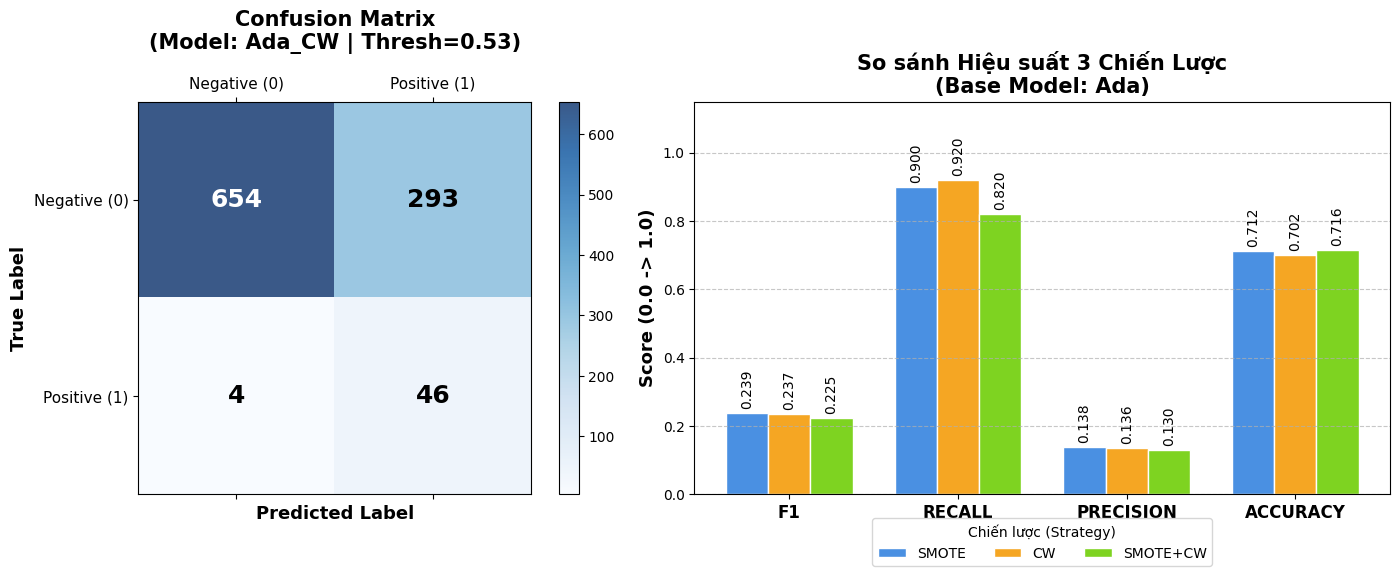

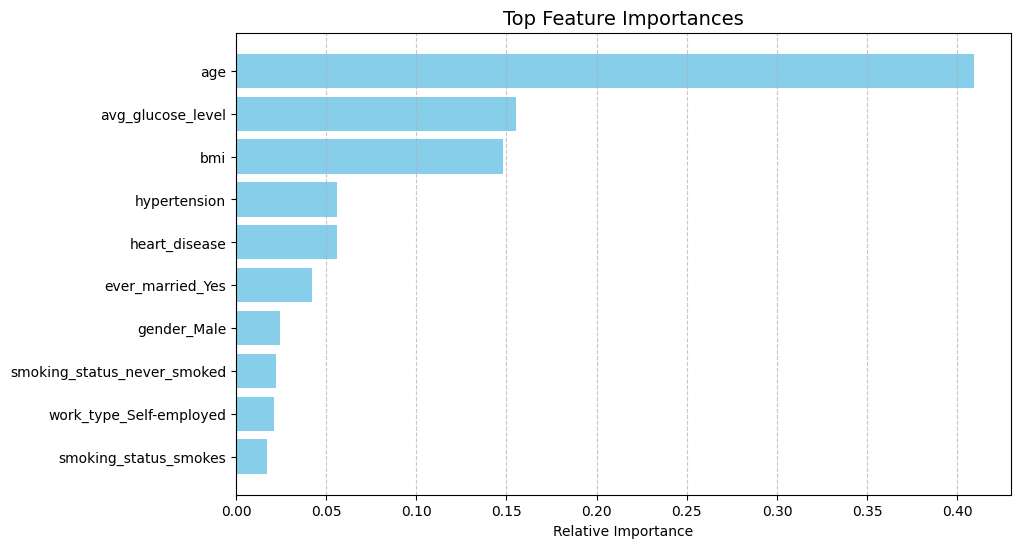

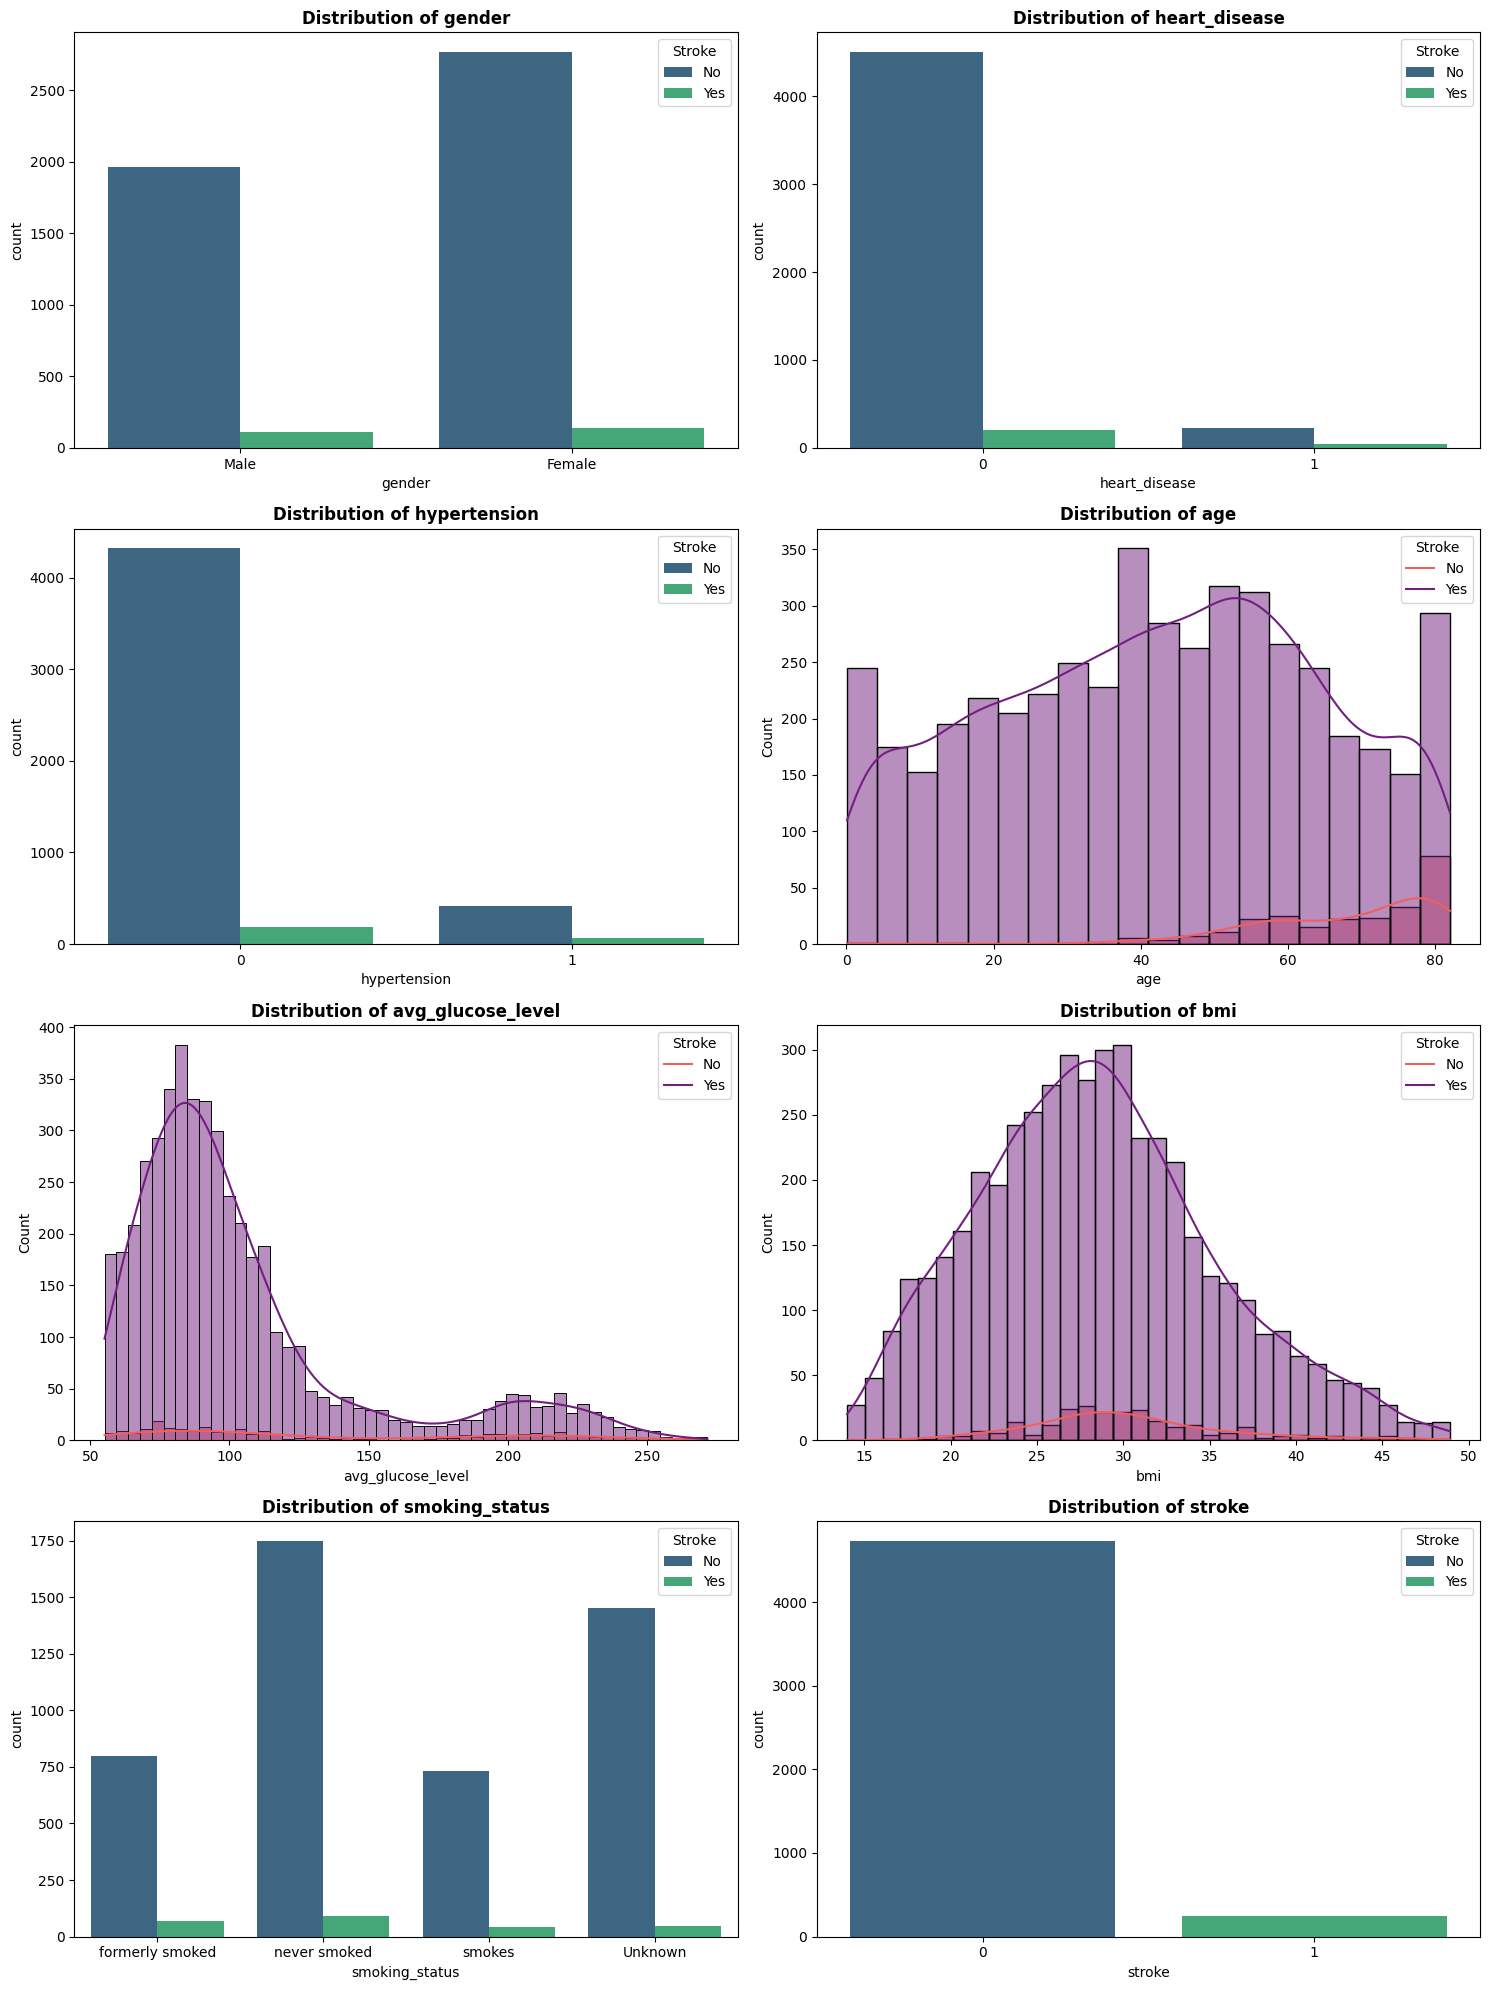

C:\Users\PC ACER\AppData\Local\Temp\ipykernel_22040\1229638326.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)


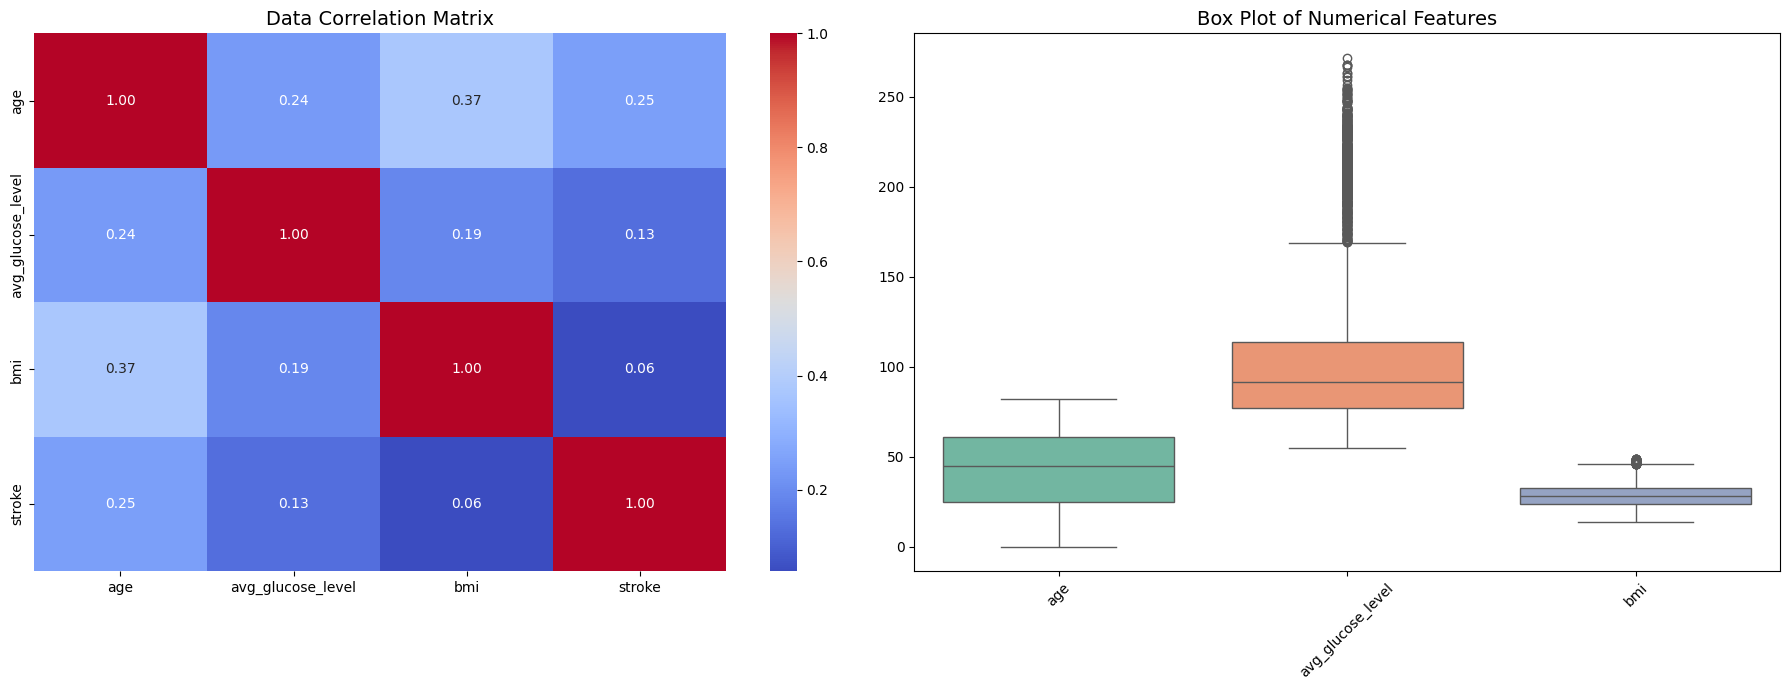

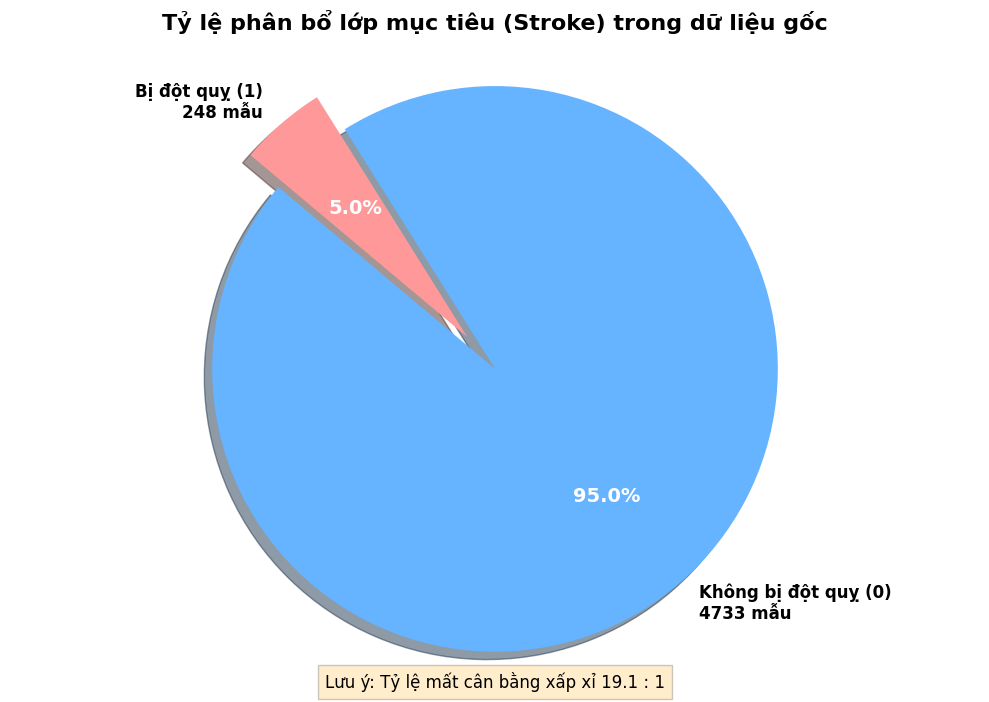

In [44]:

import matplotlib.pyplot as plt
import numpy as np

# 1. Tìm Mô hình tốt nhất dựa trên F1-Score
best_key = max(all_results, key=lambda k: all_results[k]['recall'])
best_model = models_dict[best_key]
best_thresh = all_results[best_key]['best_threshold']

print(f" MÔ HÌNH XUẤT SẮC NHẤT TOÀN CỤC: {best_key}")
print(f"   > Ngưỡng Quyết định (Threshold) tối ưu: {best_thresh:.4f}")
print(f"   > F1-Score đạt: {all_results[best_key]['f1']:.4f}")

# 2. Tạo dự đoán để vẽ Confusion Matrix
y_test_proba = best_model.predict_proba(X_test_proc)[:, 1]
y_test_pred = (y_test_proba >= best_thresh).astype(int)

# Dùng hàm CM từ scratch của bạn
cm = confusion_matrix_scratch(y_test_proc, y_test_pred)

# 3. Setup Biểu đồ (1 hình gồm 2 đồ thị)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# ĐỒ THỊ 1: CONFUSION MATRIX CỦA MÔ HÌNH TỐT NHẤT
# ---------------------------------------------------------
cax = ax1.matshow(cm, cmap='Blues', alpha=0.8)
fig.colorbar(cax, ax=ax1, fraction=0.046, pad=0.04)

# Viết số lượng vào giữa các ô vuông
for (i, j), z in np.ndenumerate(cm):
    ax1.text(j, i, f'{z}', ha='center', va='center', fontsize=18, 
             color='white' if z > np.max(cm)/2 else 'black', fontweight='bold')

ax1.set_title(f'Confusion Matrix\n(Model: {best_key} | Thresh={best_thresh:.2f})', fontsize=15, pad=20, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=13, fontweight='bold')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Negative (0)', 'Positive (1)'], fontsize=11)
ax1.set_yticklabels(['Negative (0)', 'Positive (1)'], fontsize=11)



# ĐỒ THỊ 2: BAR CHART SO SÁNH 3 CHIẾN LƯỢC CỦA MÔ HÌNH ĐÓ

base_model_name = best_key.split('_')[0] # Trích xuất tên (VD: RF, Stack)
strats = ['SMOTE', 'CW', 'SMOTE+CW']
metrics = ['f1', 'recall', 'precision', 'accuracy']
colors = ['#4A90E2', '#F5A623', '#7ED321'] # Xanh da trời, Cam, Xanh lá

x = np.arange(len(metrics))  
width = 0.25  

# Vẽ từng cột cho mỗi chiến lược
for idx, strat in enumerate(strats):
    key = f"{base_model_name}_{strat}"
    if key in all_results:
        res = all_results[key]
        vals = [res[m] for m in metrics]
        
        # Vẽ Bar
        bars = ax2.bar(x + idx*width - width, vals, width, label=strat, color=colors[idx], edgecolor='white')
        
        # Thêm text giá trị lên đỉnh cột
        for bar in bars:
            height = bar.get_height()
            ax2.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # Đẩy lên 3 points
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, rotation=90)

ax2.set_ylabel('Score (0.0 -> 1.0)', fontsize=13, fontweight='bold')
ax2.set_title(f'So sánh Hiệu suất 3 Chiến Lược\n(Base Model: {base_model_name})', fontsize=15, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([m.upper() for m in metrics], fontsize=12, fontweight='bold')
ax2.legend(title='Chiến lược (Strategy)', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3)
ax2.set_ylim(0, 1.15) # Dư khoảng trống phía trên cho Text
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

def plot_feature_importance(model, feature_names, top_n=10):
    # Lấy feature importances (áp dụng cho các model dạng Tree)
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]
    
    plt.figure(figsize=(10, 6))
    plt.title('Top Feature Importances', fontsize=14)
    plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# Sử dụng:
best_rf = models_dict['RF_CW'].best_estimator_
plot_feature_importance(best_rf, feature_cols)

def plot_distributions(df):
    cols_to_plot = ['gender', 'heart_disease', 'hypertension', 'age', 
                    'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
    
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
    axes = axes.flatten()
    
    for i, col in enumerate(cols_to_plot):
        if df[col].dtype == 'object' or df[col].nunique() <= 5:
            # Biến phân loại: Countplot
            sns.countplot(data=df, x=col, hue='stroke', ax=axes[i], palette='viridis')
        else:
            # Biến số: Histplot/KDE
            sns.histplot(data=df, x=col, hue='stroke', kde=True, ax=axes[i], palette='magma')
        
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].legend(title='Stroke', labels=['No', 'Yes']) if i >= 0 else None

    plt.tight_layout()
    plt.show()

# Sử dụng:
plot_distributions(first_dataset)


def plot_correlation_and_box(df, numeric_cols):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # 1. Ma trận tương quan
    corr = df[numeric_cols + ['stroke']].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax1)
    ax1.set_title('Data Correlation Matrix', fontsize=14)
    
    # 2. Boxplot cho các biến số (đã chuẩn hóa hoặc chưa)
    sns.boxplot(data=df[numeric_cols], ax=ax2, palette='Set2')
    ax2.set_title('Box Plot of Numerical Features', fontsize=14)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()

# Sử dụng:
plot_correlation_and_box(first_dataset, ['age', 'avg_glucose_level', 'bmi'])
def compare_metrics_table(results_dict):
    """
    results_dict nên chứa metrics cho từng tập dữ liệu.
    """
    # Tạo DataFrame từ dictionary kết quả
    comparison_df = pd.DataFrame(results_dict).T
    
    # Định dạng bảng màu
    styled_df = comparison_df.style.background_gradient(cmap='Blues', subset=['AUC', 'F1', 'Recall'])\
                             .format("{:.4f}")
    print("=== Model Performance Statistics (Comparison) ===")
    return styled_df
def plot_stroke_ratio_pie(df):
    stroke_counts = df['stroke'].value_counts()
    labels = [f'Không bị đột quỵ (0)\n{stroke_counts[0]} mẫu', 
              f'Bị đột quỵ (1)\n{stroke_counts[1]} mẫu']
    sizes = [stroke_counts[0], stroke_counts[1]]
    colors = ['#66b3ff', '#ff9999'] 
    explode = (0, 0.15)  
    plt.figure(figsize=(10, 7))
    patches, texts, autotexts = plt.pie(
        sizes, 
        explode=explode, 
        labels=labels, 
        colors=colors,
        autopct='%1.1f%%', # Hiển thị phần trăm
        shadow=True, 
        startangle=140,
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(14)
    plt.title('Tỷ lệ phân bổ lớp mục tiêu (Stroke) trong dữ liệu gốc', 
              fontsize=16, fontweight='bold', pad=20)
    ratio = stroke_counts[0] / stroke_counts[1]
    plt.figtext(0.5, 0.01, f"Lưu ý: Tỷ lệ mất cân bằng xấp xỉ {ratio:.1f} : 1", 
                ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    plt.axis('equal') 
    plt.tight_layout()
    plt.show()
# Sử dụng:
plot_stroke_ratio_pie(first_dataset)


# Kết nối Backend

In [ ]:
# ── API STROKE PREDICTION (PHIÊN BẢN HOÀN THIỆN ĐỒNG BỘ CSDL) ──

import pandas as pd
import numpy as np
import threading
import time
from flask import Flask, request, jsonify
from pyngrok import ngrok

# Cấu hình Token Ngrok
NGROK_TOKEN = "3D14BfVgHViIvhv9oTOOMUcQZIB_7SqJXpYkQzsSvwnCJaAJb" 
ngrok.set_auth_token(NGROK_TOKEN)

app = Flask(__name__)

def preprocess_stroke_data(payload: dict) -> pd.DataFrame:
    df_input = pd.DataFrame([payload])
    
    # 1. Xử lý giá trị thiếu cho BMI (Dùng median đã lưu)
    if 'bmi' in df_input.columns and (df_input['bmi'].isnull().any() or df_input['bmi'].iloc[0] is None):
        df_input['bmi'] = df_input['bmi'].fillna(model_artifacts['bmi_median'])
        
    # 2. Xử lý Outlier (Clip giá trị theo report đã lưu)
    for col, bounds in model_artifacts['outlier_report'].items():
        if col in df_input.columns:
            df_input[col] = df_input[col].clip(bounds['lower'], bounds['upper'])
    # 3. Encoding (Đảm bảo khớp format với training)
    # Thay thế khoảng trắng bằng gạch dưới như lúc train
    for col in df_input.select_dtypes(include=['object']).columns:
        df_input[col] = df_input[col].astype(str).str.replace(' ', '_')
        
    df_encoded = pd.get_dummies(df_input)
    
    # Reindex để đảm bảo đủ số cột và đúng thứ tự như lúc train
    df_encoded = df_encoded.reindex(columns=model_artifacts['feature_cols'], fill_value=0)
            
    # 4. Scaling (Dùng stats chuẩn từ artifacts)
    stats = model_artifacts['scaling_stats']
    for col in ['age', 'avg_glucose_level', 'bmi']:
        if col in stats:
            s = stats[col]
            denom = s['max'] - s['min']
            df_encoded[col] = (df_encoded[col] - s['min']) / denom if denom > 0 else 0
            
    return df_encoded
def get_prediction(payload: dict):
    # Lấy mô hình và ngưỡng tối ưu từ Artifacts
    model = model_artifacts['model'].best_estimator_
    thresh = model_artifacts['best_threshold']
    
    X_input = preprocess_stroke_data(payload)
    prob = model.predict_proba(X_input.values)[0][1] 
    
    # Dùng ngưỡng tối ưu thay vì 0.5 cố định
    label = 1 if prob >= thresh else 0
    
    # Phân loại mức độ rủi ro (Risk Level)
    if prob < 0.20: risk_text = "Rất thấp (Very Low)"
    elif prob < 0.40: risk_text = "Thấp (Low)"
    elif prob < 0.60: risk_text = "Trung bình (Medium)"
    elif prob < 0.85: risk_text = "Cao (High)"
    else: risk_text = "Rất cao (Critical)"
    
    return {
        "prediction": int(label),
        "probability": round(float(prob), 4),
        "threshold_used": round(float(thresh), 4),
        "risk_level": risk_text,
        "message": f"Dự đoán từ AI Model: {target_model_key}"
    }

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json(force=True)
        payload = data.get("input", data) 
        result = get_prediction(payload)
        return jsonify({"success": True, "result": result}), 200
    except Exception as e:
        return jsonify({'success': False, 'error': str(e)}), 500

@app.route('/predict/batch', methods=['POST'])
def predict_batch():
    try:
        data = request.get_json(force=True)
        patients = data.get('patients', [])
        results = [get_prediction(p) for p in patients]
        return jsonify({'success': True, 'total': len(patients), 'results': results}), 200
    except Exception as e:
        return jsonify({'success': False, 'error': str(e)}), 500

def run_flask():
    app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)

# Khởi chạy
for t in ngrok.get_tunnels(): ngrok.disconnect(t.public_url)
threading.Thread(target=run_flask, daemon=True).start()
time.sleep(2)
public_url = ngrok.connect(5000, bind_tls=True)

print("="*60)
print(f"🚀 API HOÀN CHỈNH ĐANG CHẠY TẠI: {public_url.public_url}")
print(" Link này đã khớp hoàn toàn với CSDL PostgreSQL của bạn.")
print("="*60)


t=2026-05-14T09:22:47+0700 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="failed to send authentication request: failed to fetch CRL. errors encountered: Get \"http://crl.ngrok-agent.com/ngrok.crl\": read tcp [2405:4802:186f:7c70:d1fe:ea5f:e18:ea5c]:51364->[2600:9000:269c:8200:8:ba10:9900:93a1]:80: wsarecv: An existing connection was forcibly closed by the remote host."
t=2026-05-14T09:22:50+0700 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="failed to send authentication request: failed to fetch CRL. errors encountered: Get \"http://crl.ngrok-agent.com/ngrok.crl\": read tcp [2405:4802:186f:7c70:d1fe:ea5f:e18:ea5c]:51368->[2600:9000:269c:8200:8:ba10:9900:93a1]:80: wsarecv: An existing connection was forcibly closed by the remote host."


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.1.75:5000
Press CTRL+C to quit


🚀 API HOÀN CHỈNH ĐANG CHẠY TẠI: https://kilt-defeat-barley.ngrok-free.dev
 Link này đã khớp hoàn toàn với CSDL PostgreSQL của bạn.


t=2026-05-14T11:26:26+0700 lvl=eror msg="heartbeat timeout, terminating session" obj=tunnels.session obj=csess id=6b705d59e8c8 clientid=6503e109b07bd72bb086419b20ee6a37
t=2026-05-14T11:26:26+0700 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=d60988590415 err="session closed"
t=2026-05-14T14:58:33+0700 lvl=eror msg="heartbeat timeout, terminating session" obj=tunnels.session obj=csess id=12d610b3d8ae clientid=6503e109b07bd72bb086419b20ee6a37
t=2026-05-14T14:58:33+0700 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=d60988590415 err="session closed"
t=2026-05-14T14:58:34+0700 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="failed to dial ngrok server with address \"connect.us.ngrok-agent.com:443\": dial tcp: lookup connect.us.ngrok-agent.com: no such host"
t=2026-05-14T14:58:34+0700 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="failed to dial ngrok server with addre

# Kết quả khi không áp dụng sử lý Imbalanced

In [46]:
# ==================================================================
# CELL: PIPELINE ĐÁNH GIÁ TRÊN DỮ LIỆU GỐC (BASELINE)
# ==================================================================
import numpy as np
from sklearn.model_selection import train_test_split

# --- PHẦN 1: HÀM BỔ TRỢ (GIỮ NGUYÊN ĐỂ TÌM NGƯỠNG) ---

def _get_curve_data_scratch(y_true, y_proba):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    desc_score_indices = np.argsort(y_proba)[::-1]
    y_true_sorted      = y_true[desc_score_indices]
    y_proba_sorted     = y_proba[desc_score_indices]
    distinct_value_indices = np.where(np.diff(y_proba_sorted))[0]
    threshold_idxs         = np.r_[distinct_value_indices, y_true_sorted.size - 1]
    thresholds             = y_proba_sorted[threshold_idxs]
    tps = np.cumsum(y_true_sorted)[threshold_idxs]
    fps = (1 + threshold_idxs) - tps
    return tps, fps, thresholds

def find_best_threshold(y_true, y_proba, metric='gmean'):
    y_true  = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    tps, fps, thresholds = _get_curve_data_scratch(y_true, y_proba)
    P = np.sum(y_true == 1)
    N = len(y_true) - P
    if metric == 'f1':
        scores = 2*(tps/(tps+fps+1e-15)*(tps/(P+1e-15))) / (tps/(tps+fps+1e-15)+(tps/(P+1e-15))+1e-15)
    elif metric == 'gmean':
        scores = np.sqrt((tps/(P+1e-15)) * (1 - (fps/(N+1e-15))))
    elif metric == 'accuracy':
        scores = (tps + (N - fps)) / (P + N)
    else: scores = tps / (P + 1e-15)
    best_idx = np.argmax(scores)
    return float(np.clip(thresholds[best_idx], 0.0, 1.0)), float(scores[best_idx])

def evaluate_baseline_pipeline(model, X_val, y_val, X_test, y_test, model_name="Model", metric='gmean'):
    mdl = model.best_estimator_ if hasattr(model, 'best_estimator_') else model
    y_val_proba = mdl.predict_proba(X_val)[:, 1]
    best_thresh, _ = find_best_threshold(y_val, y_val_proba, metric=metric)
    print(f"  [Threshold Tuning] {model_name:<12} | Best Thresh = {best_thresh:.4f}")
    y_test_proba = mdl.predict_proba(X_test)[:, 1]
    y_test_pred  = (y_test_proba >= best_thresh).astype(int)
    metrics = compute_metrics(y_test, y_test_pred, y_test_proba, model_name)
    metrics['best_threshold'] = best_thresh
    return metrics

# --- PHẦN 2: CHUẨN BỊ DỮ LIỆU ---
X_train_fit, X_val_thresh, y_train_fit, y_val_thresh = train_test_split(
    X_train.copy(), y_train.copy(), test_size=0.2, stratify=y_train, random_state=42
)

all_baseline_results = {}
baseline_models = {}

# Hyperparameter Grids
dt_pg  = {'max_depth': [5, 10], 'min_samples_split': [2, 5], 'criterion': ['gini', 'entropy']}
rf_pg  = {'n_estimators': [20, 50], 'max_depth': [5, 10], 'max_features': ['sqrt']}
knn_pg = {'n_neighbors': [3, 5, 7], 'metric': ['euclidean', 'manhattan'], 'weights': ['uniform', 'distance']}
ada_pg = {'n_estimators': [30, 80], 'learning_rate': [0.01, 0.001]}

# --- PHẦN 3: HUẤN LUYỆN TRỰC TIẾP (BASELINE STRATEGY) ---
print("\n" + "="*30 + " TRAINING ON ORIGINAL DATA (BASELINE) " + "="*30)

# 1. Decision Tree
gs_dt = GridSearch(DecisionTree, dt_pg, cv=5, scoring='auc', model_name='DT-Base').fit(X_train_fit, y_train_fit)
all_baseline_results['DT'] = evaluate_baseline_pipeline(gs_dt, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "DT")

# 2. Random Forest
gs_rf = GridSearch(RandomForest, rf_pg, cv=5, scoring='auc', model_name='RF-Base').fit(X_train_fit, y_train_fit)
all_baseline_results['RF'] = evaluate_baseline_pipeline(gs_rf, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "RF")

# 3. KNN
gs_knn = GridSearch(KNN, knn_pg, cv=5, scoring='auc', model_name='KNN-Base').fit(X_train_fit, y_train_fit)
all_baseline_results['KNN'] = evaluate_baseline_pipeline(gs_knn, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "KNN")

# 4. AdaBoost
gs_ada = GridSearch(AdaBoost, ada_pg, cv=5, scoring='auc', model_name='Ada-Base').fit(X_train_fit, y_train_fit)
all_baseline_results['Ada'] = evaluate_baseline_pipeline(gs_ada, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "Ada")

# 5. Stacking (Không SMOTE, Không Class Weight)
st_base = StackingClassifier(
    base_learners=[
        ('DecisionTree', gs_dt.best_estimator_),
        ('RandomForest', gs_rf.best_estimator_),
        ('KNN',          gs_knn.best_estimator_),
        ('AdaBoost',     gs_ada.best_estimator_),
    ],
    meta_learner=LogisticRegressionScratch(lr=0.01) # Mặc định không class_weight
).fit(X_train_fit, y_train_fit)
all_baseline_results['Stack'] = evaluate_baseline_pipeline(st_base, X_val_thresh, y_val_thresh, X_test_proc, y_test_proc, "Stacking")

# --- PHẦN 4: BẢNG TỔNG HỢP ---
print("\n" + "═"*90)
print(f"  {'Model':<15} {'Threshold':>10} {'AUC':>8} {'F1':>8} {'Recall':>8} {'Precision':>10}")
print("  " + "─"*85)
for name in ['DT', 'RF', 'KNN', 'Ada', 'Stack']:
    r = all_baseline_results[name]
    print(f"  {name:<15} {r['best_threshold']:>10.4f} {r['auc']:>8.4f} {r['f1']:>8.4f} {r['recall']:>8.4f} {r['precision']:>10.4f}")
print("═"*90)



============================== TRAINING ON ORIGINAL DATA (BASELINE) ==============================

═════════════════════════════════════════════════════════════════
  Grid Search : DT-Base
  Scoring     : AUC | Mode: Stratified 5-Fold CV
  SMOTE       : Không | Class Weight: Không
  Tổng tổ hợp : 8
═════════════════════════════════════════════════════════════════
  [  1/8] max_depth=5, min_samples_split=2, criterion=gini auc=0.7808 ±0.0492 ← best
  [  2/8] max_depth=5, min_samples_split=2, criterion=entropy auc=0.7854 ±0.0443 ← best
  [  3/8] max_depth=5, min_samples_split=5, criterion=gini auc=0.7799 ±0.0486
  [  4/8] max_depth=5, min_samples_split=5, criterion=entropy auc=0.7848 ±0.0440
  [  5/8] max_depth=10, min_samples_split=2, criterion=gini auc=0.5703 ±0.0371
  [  6/8] max_depth=10, min_samples_split=2, criterion=entropy auc=0.6539 ±0.0508
  [  7/8] max_depth=10, min_samples_split=5, criterion=gini auc=0.5822 ±0.0337
  [  8/8] max_depth=10, min_samples_split=5, criterion=entro